<a href="https://colab.research.google.com/github/Ahmad860187/AES-Cryptography/blob/main/channel_charting_v5_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Channel Charting with Learned Feature Weights

**Pipeline (per dataset, per elapsed_s mode):**
1. Load CellMob data, build features (per-source rolling mean)
2. Train/test split via temporal decimation (stride 4)
3. Standardise + impute using TRAIN statistics only
4. Learn M2 (L-BFGS-B) optimal feature weights on TRAIN split
5. Compute dissimilarity on TEST split (Baselines A, B, C)
6. Embed into 2D via Classical MDS
7. Evaluate: Spearman ρ, Trustworthiness, Continuity
8. Plot channel charts vs GPS; save CSV summary

**Ablation:** runs with and without `elapsed_s`

## 1. Setup — Mount Google Drive & Extract Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile, glob

# ── Paths ────────────────────────────────────────────────────────────────
DRIVE_FOLDER = '/content/drive/MyDrive/cell_mob'
OUTPUT_DIR   = os.path.join(DRIVE_FOLDER, 'figures_cc_v5')  # saved TO Drive
WORK_DIR     = '/content'

# Create output folder on Drive (persists after runtime ends)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output directory: {OUTPUT_DIR}')

# ── Find and extract the zip ─────────────────────────────────────────────
zips = glob.glob(os.path.join(DRIVE_FOLDER, '*.zip'))
if not zips:
    raise FileNotFoundError(
        f'No .zip file found in {DRIVE_FOLDER}.\n'
        f'Contents: {os.listdir(DRIVE_FOLDER) if os.path.isdir(DRIVE_FOLDER) else "FOLDER NOT FOUND"}')

zip_path = zips[0]
print(f'Found zip: {zip_path}')

import os, shutil
# Remove old CellMob symlink/folder
link = '/content/CellMob'
if os.path.islink(link):
    os.unlink(link)
elif os.path.exists(link):
    shutil.rmtree(link, ignore_errors=True)
# Remove previously extracted dataset folders from /content
for item in os.listdir('/content'):
    path = os.path.join('/content', item)
    if item in ['drive', 'sample_data'] or item.startswith('.'):
        continue
    if os.path.isdir(path):
        shutil.rmtree(path, ignore_errors=True)

# Extract to /content (fast local disk, not Drive)
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(WORK_DIR)

# Auto-detect the extracted folder name
cellmob_dir = None
for c in os.listdir(WORK_DIR):
    path = os.path.join(WORK_DIR, c)
    if not os.path.isdir(path):
        continue
    subdirs = [s for s in os.listdir(path)
               if os.path.isdir(os.path.join(path, s)) and not s.startswith('.')]
    for sd in subdirs:
        if glob.glob(os.path.join(path, sd, '*.csv')):
            cellmob_dir = path
            break
    if cellmob_dir:
        break

if cellmob_dir is None:
    print('⚠ Could not auto-detect CellMob folder. Contents of /content:')
    for item in sorted(os.listdir(WORK_DIR)):
        print(f'  {item}/')
    raise FileNotFoundError('Set cellmob_dir manually below, then re-run.')

# Symlink to a standard name
link = os.path.join(WORK_DIR, 'CellMob')
if not os.path.exists(link):
    if os.path.abspath(cellmob_dir) != os.path.abspath(link):
        os.symlink(cellmob_dir, link)

os.chdir(WORK_DIR)
datasets = sorted(d for d in os.listdir('CellMob')
                  if os.path.isdir(os.path.join('CellMob', d)) and not d.startswith('.'))
print(f'\nDatasets found ({len(datasets)}): {datasets}')
print(f'\n✓ Data extracted to local disk (fast I/O)')
print(f'✓ Results will be saved to Google Drive: {OUTPUT_DIR}')


Mounted at /content/drive
Output directory: /content/drive/MyDrive/cell_mob/figures_cc_v5
Found zip: /content/drive/MyDrive/cell_mob/CellMob.zip

Datasets found (12): ['bus_colored_kaust', 'bus_jeddah', 'bus_mekkah', 'car_jeddah', 'car_kaust', 'car_kz', 'car_mekkah', 'train_mekkah', 'walk_jeddah', 'walk_kaust', 'walk_kz', 'walk_mekkah']

✓ Data extracted to local disk (fast I/O)
✓ Results will be saved to Google Drive: /content/drive/MyDrive/cell_mob/figures_cc_v5


## 2. Imports & Configuration

In [ ]:
import pathlib, warnings, time
import pandas as pd, numpy as np
from scipy.stats import spearmanr
from scipy.optimize import minimize
import scipy.spatial
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(42)

# ═══════════════════════════════════════════════════════════════════════
#  Configuration — matches metric_learn.py exactly
# ═══════════════════════════════════════════════════════════════════════
PCI_COL  = 'Physical cell identity (LTE pcell)'
TIME_BIN = '5s'
HIST     = 10          # rolling-mean window
STEP     = 8           # Spearman eval subsampling (matches original)

STRIDE       = 4       # decimation stride
TRAIN_OFFSET = 0       # train: i % STRIDE == 0
TEST_OFFSET  = 2       # test:  i % STRIDE == 2

# MDS / T&C config (new, not in original)
MAX_MDS_SAMPLES = 2000
K_TC = 20
MAX_TC_SAMPLES = 800
TOP_K = 5

EXCLUDE_COLS = {
    'Time', 'TimeParsed', 'source', PCI_COL,
    'Latitude', 'Longitude', 'Velocity', 'TimeBin',
    'Cell identification', 'Channel number (LTE pcell)',
    'Handover U-plane interruption time', 'Handover duration',
    'Handover/handoff attempts',
}

print('✓ Configuration loaded (matching metric_learn.py)')


✓ Configuration loaded (matching metric_learn.py)


## 3. Data Loading Utilities

In [ ]:
def load_file(path, src):
    d = pd.read_csv(path, low_memory=False)
    d['TimeParsed'] = pd.to_datetime(d['Time'], format='%H:%M:%S.%f', errors='coerce')
    d = d.dropna(subset=['TimeParsed']).sort_values('TimeParsed').reset_index(drop=True)
    d['source'] = src
    d[PCI_COL] = d[PCI_COL].ffill()
    d = d.dropna(subset=[PCI_COL])
    d[PCI_COL] = d[PCI_COL].astype(int).astype(str)
    for c in d.columns:
        if c not in ('Time', 'TimeParsed', 'source', PCI_COL):
            d[c] = pd.to_numeric(d[c], errors='coerce')
    return d


def load_dataset(name):
    data_dir = pathlib.Path('CellMob') / name
    frames = [load_file(p, i) for i, p in enumerate(sorted(data_dir.glob('*.csv')))]
    df = pd.concat(frames, ignore_index=True)
    df['TimeBin'] = df['TimeParsed'].dt.floor(TIME_BIN)
    return df


def latlon_to_m(lat, lon):
    lat0 = np.deg2rad(np.nanmean(lat))
    lon0 = np.deg2rad(np.nanmean(lon))
    R = 6_371_000.
    x = (np.deg2rad(lon) - lon0) * np.cos(lat0) * R
    y = (np.deg2rad(lat) - lat0) * R
    return np.column_stack([x, y]).astype(np.float32)


def build_features(df, feat_cols, include_elapsed):
    """Matches metric_learn.py exactly:
    1. Aggregate per time-bin
    2. Add elapsed_s (if requested)
    3. Rolling mean across full table (original behavior)
    """
    agg = df.groupby(['source', 'TimeBin'])[feat_cols].mean().sort_index()

    # Session-relative elapsed time (added BEFORE rolling, same as original)
    if include_elapsed:
        sources_arr = np.array([s for s, _ in agg.index])
        times_ns    = np.array([b.value for _, b in agg.index], dtype=np.float64)
        elapsed = np.zeros(len(agg))
        for src in np.unique(sources_arr):
            mask = (sources_arr == src)
            t = times_ns[mask]
            elapsed[mask] = (t - t.min()) / 1e9
        agg = agg.copy()
        agg['elapsed_s'] = elapsed

    feat_names = list(agg.columns)

    # Flatten index THEN rolling (matches original: rolling across all sources)
    agg.index = [f'{s}_{b}' for s, b in agg.index]
    if HIST > 0:
        agg = agg.rolling(HIST + 1, min_periods=1).mean()

    # GPS ground truth
    gps = (df[df['Latitude'].notna()]
           .groupby(['source', 'TimeBin'])
           .agg(lat=('Latitude', 'mean'), lon=('Longitude', 'mean'))
           .reset_index())
    gps['key'] = gps['source'].astype(str) + '_' + gps['TimeBin'].astype(str)
    gps = gps.set_index('key')

    common = agg.index.intersection(gps.index)
    X   = agg.loc[common].values.astype(np.float32)
    g   = gps.loc[common]
    pos = latlon_to_m(g['lat'].values, g['lon'].values)
    D_gt = scipy.spatial.distance_matrix(pos, pos).astype(np.float32)
    return X, D_gt, pos, feat_names


print('✓ Data loading utilities defined (matching metric_learn.py)')


✓ Data loading utilities defined (matching metric_learn.py)


## 4. Train/Test Split & Preprocessing

In [ ]:
def decimation_split(N):
    """Temporal decimation (matches original metric_learn.py)."""
    tr = np.array([i for i in range(N) if i % STRIDE == TRAIN_OFFSET])
    te = np.array([i for i in range(N) if i % STRIDE == TEST_OFFSET])
    return tr, te


def preprocess(X, tr_idx):
    """Matches original: nan_to_num(0.0) then StandardScaler on train."""
    X = np.nan_to_num(X, nan=0.0).astype(np.float64)
    scl = StandardScaler().fit(X[tr_idx])
    return scl.transform(X)


print('✓ Split & preprocessing defined (matching metric_learn.py)')


✓ Split & preprocessing defined (matching metric_learn.py)


## 5. Evaluation Metrics

In [ ]:
def spearman_score(D, D_gt, step=1):
    d, g = D[::step, ::step], D_gt[::step, ::step]
    iu = np.triu_indices(d.shape[0], k=1)
    x, y = d[iu].astype(np.float64), g[iu].astype(np.float64)
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 50:
        return float('nan')
    return float(spearmanr(x[ok], y[ok]).correlation)


def trustworthiness(D_high, D_low, k=K_TC):
    """T=1 means no false neighbours were introduced by the embedding."""
    N = D_high.shape[0]
    if N <= k + 1:
        return float('nan')
    nn_high = np.argsort(D_high, axis=1)[:, 1:k+1]
    nn_low  = np.argsort(D_low, axis=1)[:, 1:k+1]
    ranks_high = np.argsort(np.argsort(D_high, axis=1), axis=1)
    T_sum = 0.0
    for i in range(N):
        set_high = set(nn_high[i])
        for j in nn_low[i]:
            if j not in set_high:
                T_sum += (ranks_high[i, j] - k)
    norm = N * k * (2 * N - 3 * k - 1)
    return 1.0 - (2.0 / max(norm, 1)) * T_sum


def continuity(D_high, D_low, k=K_TC):
    """C=1 means no true neighbours were lost in the embedding."""
    N = D_high.shape[0]
    if N <= k + 1:
        return float('nan')
    nn_high = np.argsort(D_high, axis=1)[:, 1:k+1]
    nn_low  = np.argsort(D_low, axis=1)[:, 1:k+1]
    ranks_low = np.argsort(np.argsort(D_low, axis=1), axis=1)
    C_sum = 0.0
    for i in range(N):
        set_low = set(nn_low[i])
        for j in nn_high[i]:
            if j not in set_low:
                C_sum += (ranks_low[i, j] - k)
    norm = N * k * (2 * N - 3 * k - 1)
    return 1.0 - (2.0 / max(norm, 1)) * C_sum


print('✓ Evaluation metrics defined')


✓ Evaluation metrics defined


## 6. Weighted Distance & M2 Weight Learning

In [ ]:
def wdist(X, w):
    Xw = X * np.sqrt(np.maximum(w, 0.0))[np.newaxis, :]
    return scipy.spatial.distance_matrix(Xw, Xw).astype(np.float32)


def learn_m2_weights(X_tr, Dgt_tr):
    """Matches metric_learn.py: M1 heuristic → L-BFGS-B optimisation."""
    F = X_tr.shape[1]
    N_tr = X_tr.shape[0]

    # M1: per-feature Spearman heuristic (uses STEP=8, same as original)
    feat_rhos = []
    for f in range(F):
        D_f = np.abs(np.subtract.outer(X_tr[:, f], X_tr[:, f])).astype(np.float32)
        r = spearman_score(D_f, Dgt_tr, step=STEP)
        feat_rhos.append(r if np.isfinite(r) else 0.0)
    w_sp = np.array([max(r, 0.0) for r in feat_rhos])
    w_sp_norm = w_sp / (w_sp.sum() + 1e-9)

    # Subsample for optimisation (~300 bins → ~45k pairs)
    step_opt = max(1, N_tr // 300)
    idx_sub  = np.arange(0, N_tr, step_opt)
    X_sub    = X_tr[idx_sub]
    iu_sub   = np.triu_indices(len(idx_sub), k=1)
    g_flat   = Dgt_tr[np.ix_(idx_sub, idx_sub)][iu_sub].astype(np.float64)

    def neg_pearson(log_w):
        w  = np.exp(log_w)
        Xw = X_sub * np.sqrt(w)[np.newaxis, :]
        df = np.sqrt(np.sum((Xw[iu_sub[0]] - Xw[iu_sub[1]])**2, axis=1) + 1e-12)
        mx, sx = df.mean(), df.std() + 1e-12
        mg, sg = g_flat.mean(), g_flat.std() + 1e-12
        return -np.mean((df - mx) * (g_flat - mg)) / (sx * sg)

    def neg_pearson_grad(log_w):
        w  = np.exp(log_w)
        Xw = X_sub * np.sqrt(w)[np.newaxis, :]
        raw = X_sub[iu_sub[0]] - X_sub[iu_sub[1]]
        df  = np.sqrt(np.sum((Xw[iu_sub[0]] - Xw[iu_sub[1]])**2, axis=1) + 1e-12)
        mx, sx = df.mean(), df.std() + 1e-12
        mg     = g_flat.mean()
        r      = np.mean((df - mx) * (g_flat - mg)) / (sx * (g_flat.std() + 1e-12))
        dd_dw  = 0.5 * raw**2 / df[:, None]
        coeff  = ((g_flat - mg) / (sx * (g_flat.std() + 1e-12))
                  - r * (df - mx) / (sx**2 + 1e-12))
        return -(np.mean(coeff[:, None] * dd_dw, axis=0)) * w

    res = minimize(neg_pearson, np.log(np.maximum(w_sp_norm, 1e-6)),
                   jac=neg_pearson_grad, method='L-BFGS-B',
                   options={'maxiter': 500, 'ftol': 1e-10, 'gtol': 1e-8})
    w = np.exp(res.x)
    return w / (w.sum() + 1e-9)


print('✓ Weight learning defined (matching metric_learn.py)')


✓ Weight learning defined (matching metric_learn.py)


## 7. Classical MDS & Procrustes Alignment

In [ ]:
def classical_mds(D, n_components=2):
    """Classical (Torgerson) MDS via eigendecomposition of the
    double-centred squared distance matrix."""
    N = D.shape[0]
    D2 = D.astype(np.float64) ** 2
    H = np.eye(N) - np.ones((N, N)) / N
    B = -0.5 * H @ D2 @ H
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1][:n_components]
    lam = np.maximum(eigvals[idx], 0.0)
    return eigvecs[:, idx] * np.sqrt(lam)[np.newaxis, :]


def procrustes_align(embedding, gps_pos):
    """Align embedding to GPS via Procrustes (translate, rotate, scale)."""
    emb_c = embedding - embedding.mean(axis=0)
    gps_c = gps_pos - gps_pos.mean(axis=0)
    M = emb_c.T @ gps_c
    U, S, Vt = np.linalg.svd(M)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T
    emb_rot = emb_c @ R
    scale = np.std(gps_c) / (np.std(emb_rot) + 1e-12)
    return emb_rot * scale + gps_pos.mean(axis=0)


print('✓ Classical MDS & Procrustes defined')


✓ Classical MDS & Procrustes defined


## 8. Embedding Pipeline (per baseline)

In [ ]:
def run_embedding_pipeline(X_te, Dgt_te, pos_te, weights, label):
    """Compute rho_raw on FULL test set (matches report),
    then subsample for MDS embedding + T&C."""

    N_te = X_te.shape[0]

    # ── rho_raw: computed on FULL test set with STEP=8 (matches report) ──
    D_sig_full = wdist(X_te, weights)
    rho_raw = spearman_score(D_sig_full, Dgt_te, step=STEP)

    # ── MDS: subsample if needed (MDS is O(N^3)) ─────────────────────────
    if N_te > MAX_MDS_SAMPLES:
        step_sub = max(1, N_te // MAX_MDS_SAMPLES)
        sub = np.arange(0, N_te, step_sub)
    else:
        sub = np.arange(N_te)

    D_sig_sub = D_sig_full[np.ix_(sub, sub)] if N_te > MAX_MDS_SAMPLES else D_sig_full
    Dgt_sub   = Dgt_te[np.ix_(sub, sub)]
    pos_sub   = pos_te[sub]

    # Classical MDS
    emb_cls = classical_mds(D_sig_sub)
    emb_cls_al = procrustes_align(emb_cls, pos_sub)
    D_cls = scipy.spatial.distance_matrix(emb_cls, emb_cls).astype(np.float32)
    rho_cls = spearman_score(D_cls, Dgt_sub, step=STEP)

    # Trustworthiness & Continuity
    N_sub = len(sub)
    if N_sub > MAX_TC_SAMPLES:
        tc_step = max(1, N_sub // MAX_TC_SAMPLES)
        tc = np.arange(0, N_sub, tc_step)
    else:
        tc = np.arange(N_sub)

    Dgt_tc   = Dgt_sub[np.ix_(tc, tc)]
    D_cls_tc = D_cls[np.ix_(tc, tc)]
    T_cls = trustworthiness(Dgt_tc, D_cls_tc)
    C_cls = continuity(Dgt_tc, D_cls_tc)

    return {
        'label':   label,
        'N':       len(sub),
        'rho_raw': rho_raw,     # full test set, matches report
        'rho_cls': rho_cls,     # MDS embedding
        'T_cls': T_cls, 'C_cls': C_cls,
        '_emb_cls': emb_cls_al, '_pos': pos_sub,
    }


print('✓ Embedding pipeline defined (rho_raw matches report)')


✓ Embedding pipeline defined (rho_raw matches report)


## 9. Plotting

In [ ]:
def plot_channel_chart(res_a, res_b, dataset_name, elapsed_tag, out_dir):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

    for row, res in enumerate([res_a, res_b]):
        pos = res['_pos']
        N   = len(pos)
        clr = np.arange(N)
        lbl = res['label']

        # GPS
        ax = axes[row, 0]
        ax.scatter(pos[:, 0], pos[:, 1], c=clr, cmap='viridis', s=3,
                   alpha=0.7, edgecolors='none')
        ax.set_title(f'GPS (N={N})', fontsize=9)
        ax.set_aspect('equal', adjustable='datalim')
        ax.tick_params(labelsize=6)

        # Classical MDS — show both rho_raw and rho_cls
        ax = axes[row, 1]
        sc = ax.scatter(res['_emb_cls'][:, 0], res['_emb_cls'][:, 1],
                        c=clr, cmap='viridis', s=3, alpha=0.7, edgecolors='none')
        ax.set_title(f'{lbl} — Classical MDS\n'
                     f'ρ_raw={res["rho_raw"]:.3f}  ρ_MDS={res["rho_cls"]:.3f}  '
                     f'T={res["T_cls"]:.3f}  C={res["C_cls"]:.3f}', fontsize=7.5)
        ax.set_aspect('equal', adjustable='datalim')
        ax.tick_params(labelsize=6)

    fig.suptitle(f'Channel Charting — {dataset_name}  [{elapsed_tag}]',
                 fontsize=13, fontweight='bold')
    fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.5, label='Time index')

    fname = f'cc_{dataset_name}_{elapsed_tag}'
    fig.savefig(out_dir / f'{fname}.png', dpi=200)
    plt.show()
    plt.close(fig)


## 10. Main Loop — Run Channel Charting

Runs all datasets × {with, without} elapsed_s × {Baseline A, B, C}.

  CHANNEL CHARTING WITH LEARNED FEATURE WEIGHTS

███████████████████████████████████████████████████████████████████████████
  MODE: WITH ELAPSED
███████████████████████████████████████████████████████████████████████████

───────────────────────────────────────────────────────────────────────────
  bus_colored_kaust  [with_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=2828, F=69, train=707, test=707
  Learning M2 weights (train only)...
  Active features: 8/69
    Wideband CQI for codeword 1                       37.0%
    Timing advance                                    24.4%
    CQI for codeword 1 per subband - 12               10.8%
    E-UTRAN carrier RSSI/antenna port - 6              9.8%
    E-UTRAN carrier RSSI/antenna port - 2              9.4%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ──────

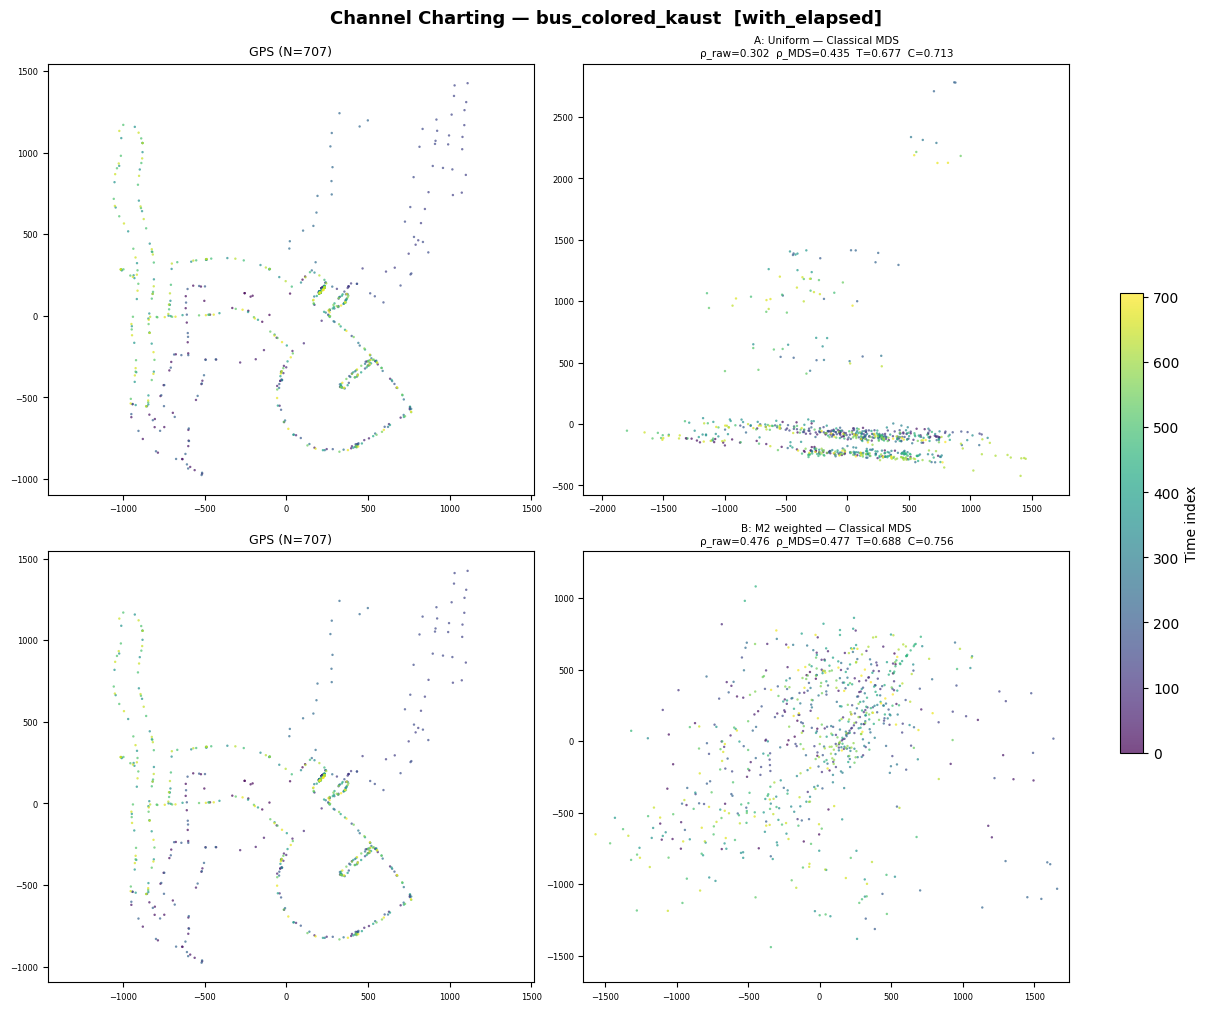

  (20s)

───────────────────────────────────────────────────────────────────────────
  bus_jeddah  [with_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=3446, F=69, train=862, test=861
  Learning M2 weights (train only)...
  Active features: 4/69
    elapsed_s                                         65.0%
    Rank indication percentage - 2                    15.4%
    RSRQ/antenna port - 1                             10.1%
    Timing advance                                     9.6%
    Rank indication percentage - 1                     0.0%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.1081 +0.0507 0.5761 0.6573
  B: M2 weighted         +0.3985 +0.3671 0.7990 0.7366
  C: Top-5 uniform       +0.2459 +0.2131 0.6832 0.7426

  Gain B−A (cMDS): +0.3164    Gain B−C 

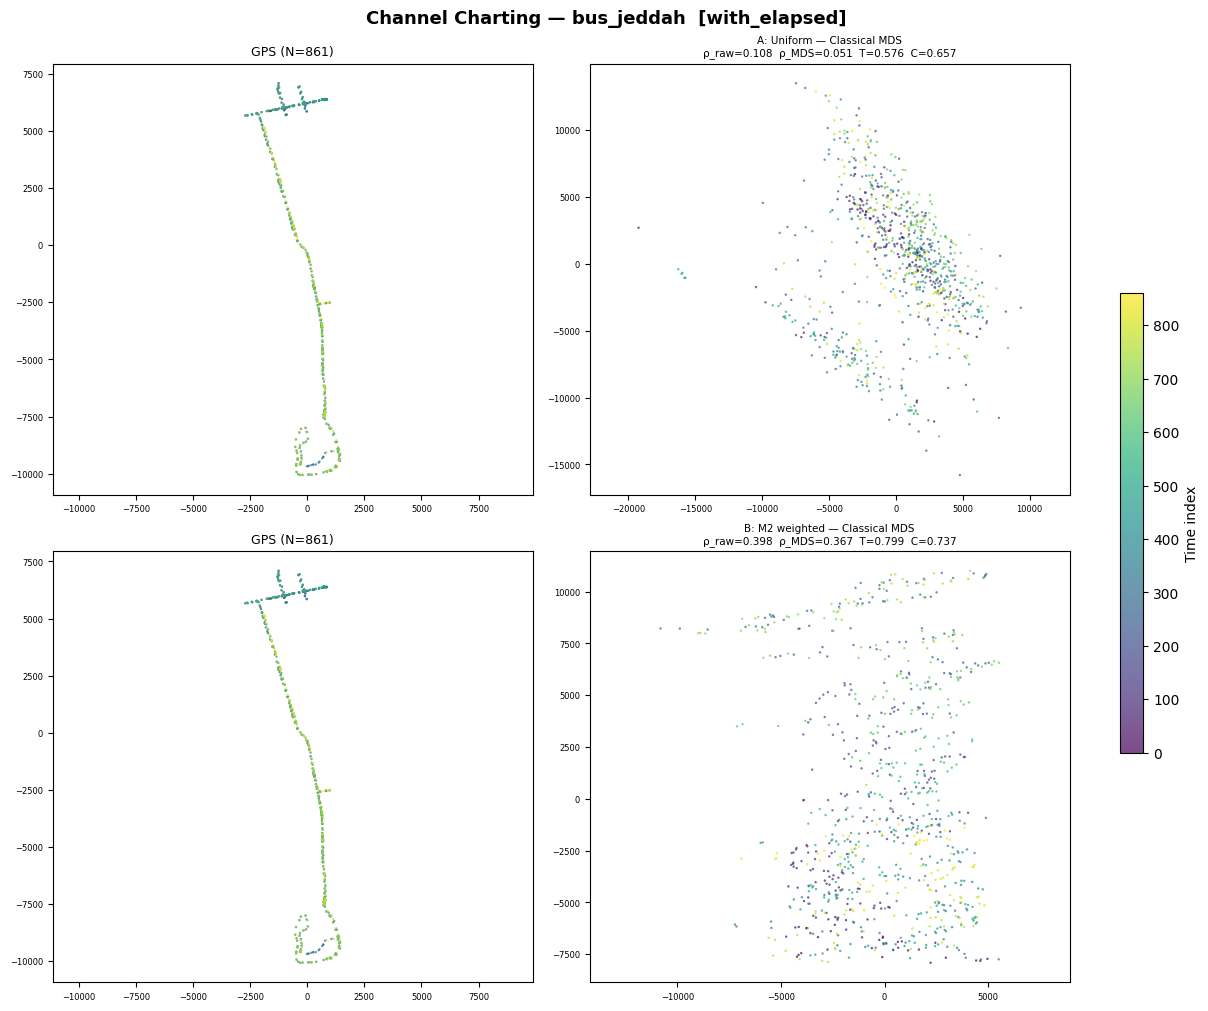

  (17s)

───────────────────────────────────────────────────────────────────────────
  bus_mekkah  [with_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=3856, F=81, train=964, test=964
  Learning M2 weights (train only)...
  Active features: 10/81
    CQI for codeword 0 per subband - 1                23.9%
    CQI for codeword 0 per subband - 11               18.3%
    CQI for codeword 0 per subband - 12                9.8%
    CQI for codeword 1 per subband - 11                8.7%
    RSRQ/antenna port - 1                              8.6%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.1999 +0.1471 0.5730 0.6773
  B: M2 weighted         +0.3507 +0.3357 0.6273 0.7086
  C: Top-5 uniform       +0.2881 +0.3164 0.6259 0.7115

  Gain B−A (cMDS): +0.1886    Gain B−C

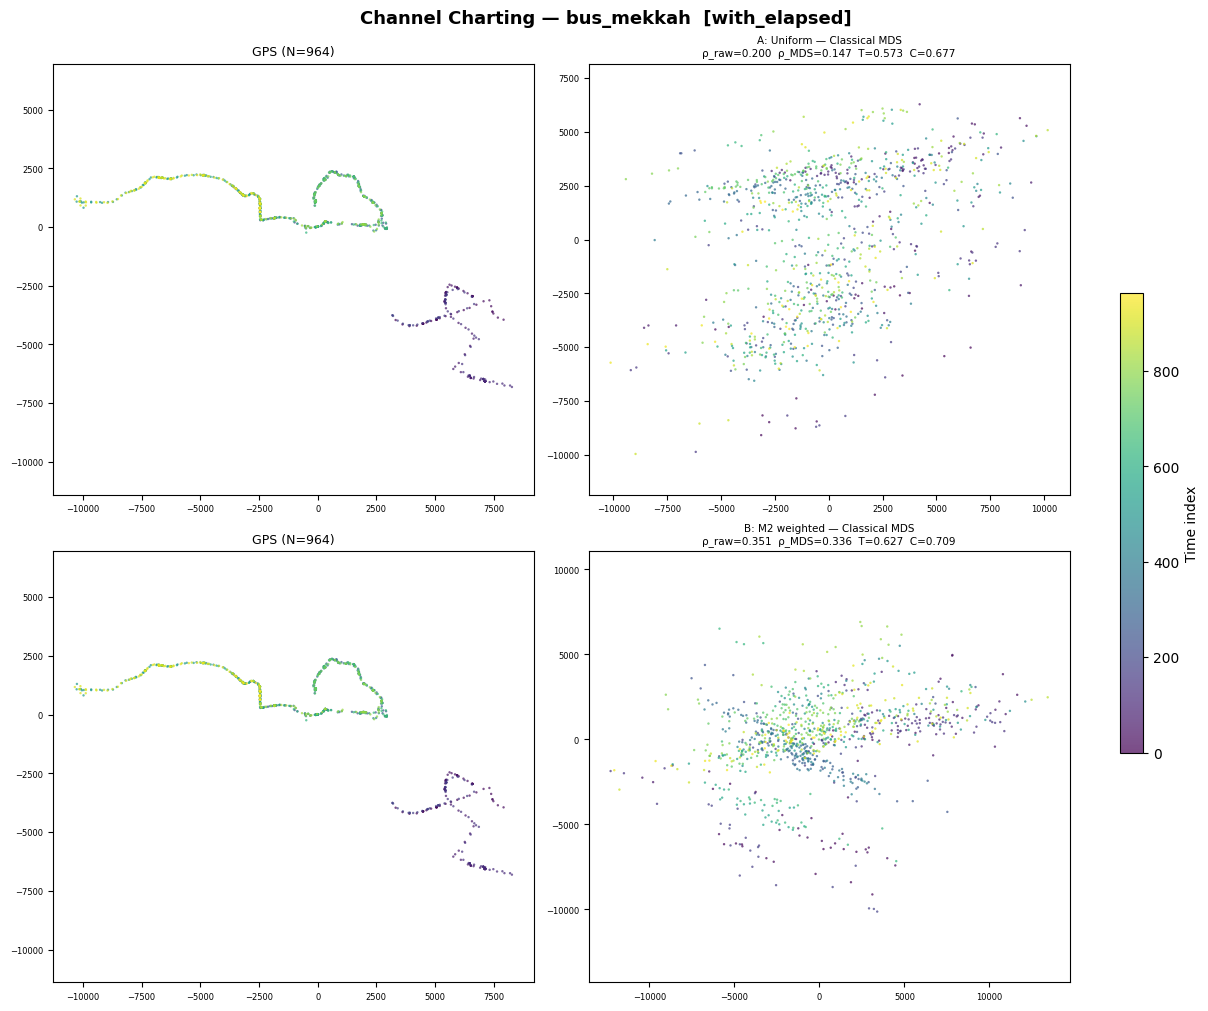

  (23s)

───────────────────────────────────────────────────────────────────────────
  car_jeddah  [with_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=4679, F=75, train=1170, test=1170
  Learning M2 weights (train only)...
  Active features: 12/75
    elapsed_s                                         30.8%
    RSRP/antenna port - 7                             11.0%
    RSRQ/antenna port - 1                             10.4%
    E-UTRAN carrier RSSI/antenna port - 2             10.1%
    RSRQ/antenna port - 3                              8.1%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.2521 +0.2914 0.6501 0.7155
  B: M2 weighted         +0.5733 +0.5541 0.7658 0.7822
  C: Top-5 uniform       +0.5595 +0.5559 0.7392 0.8048

  Gain B−A (cMDS): +0.2627    Gain B

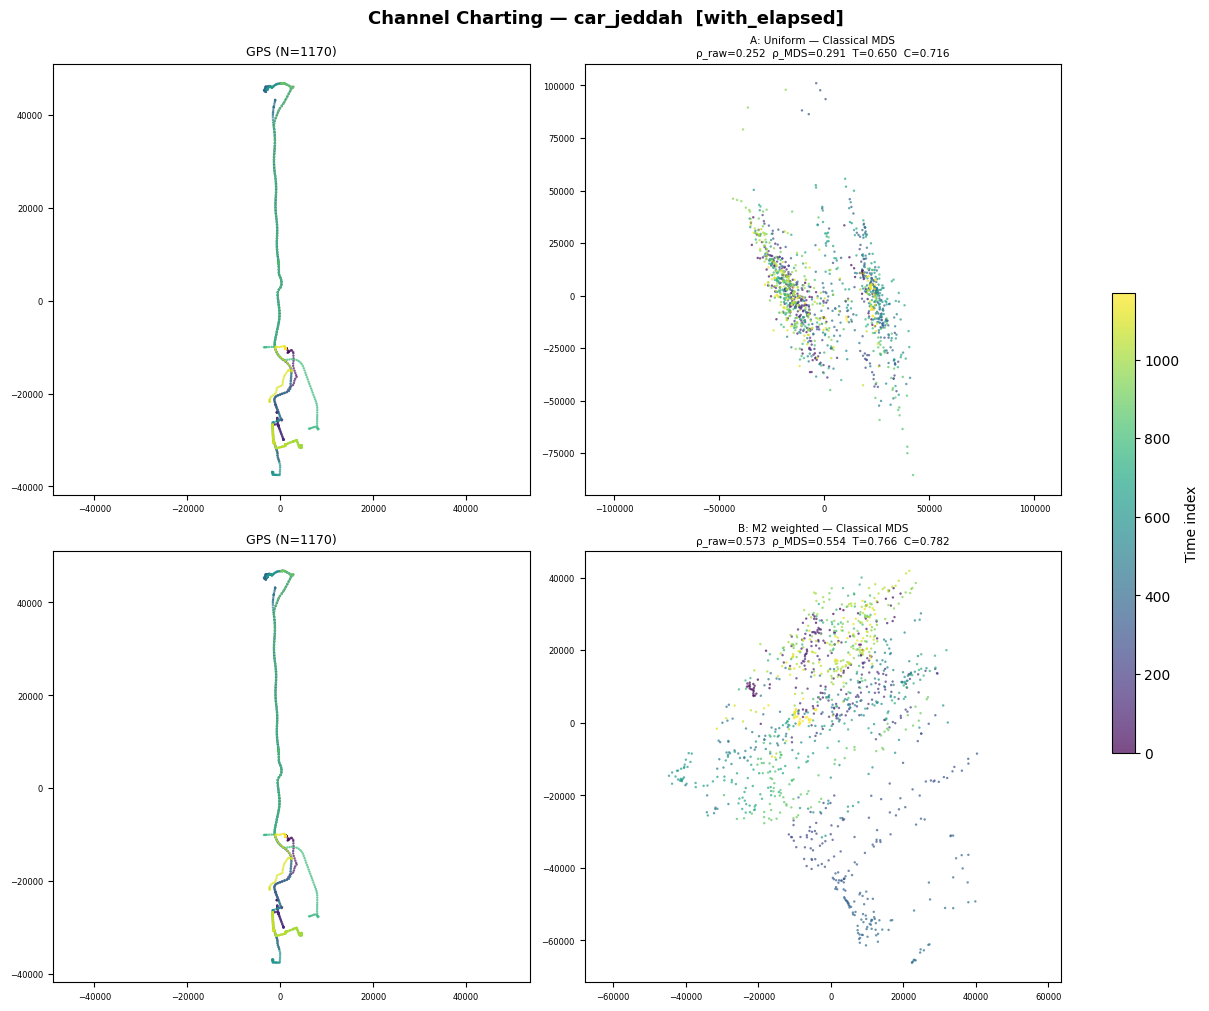

  (36s)

───────────────────────────────────────────────────────────────────────────
  car_kaust  [with_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=2016, F=69, train=504, test=504
  Learning M2 weights (train only)...
  Active features: 5/69
    CQI for codeword 1 per subband - 11               38.9%
    RSRQ/antenna port - 1                             22.5%
    E-UTRAN carrier RSSI/antenna port - 4             20.8%
    Timing advance                                    11.6%
    RSRP/antenna port - 2                              6.1%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.1032 +0.0890 0.6260 0.6769
  B: M2 weighted         +0.1614 +0.1143 0.6771 0.7362
  C: Top-5 uniform       +0.1674 +0.1275 0.6648 0.7391

  Gain B−A (cMDS): +0.0253    Gain B−C (

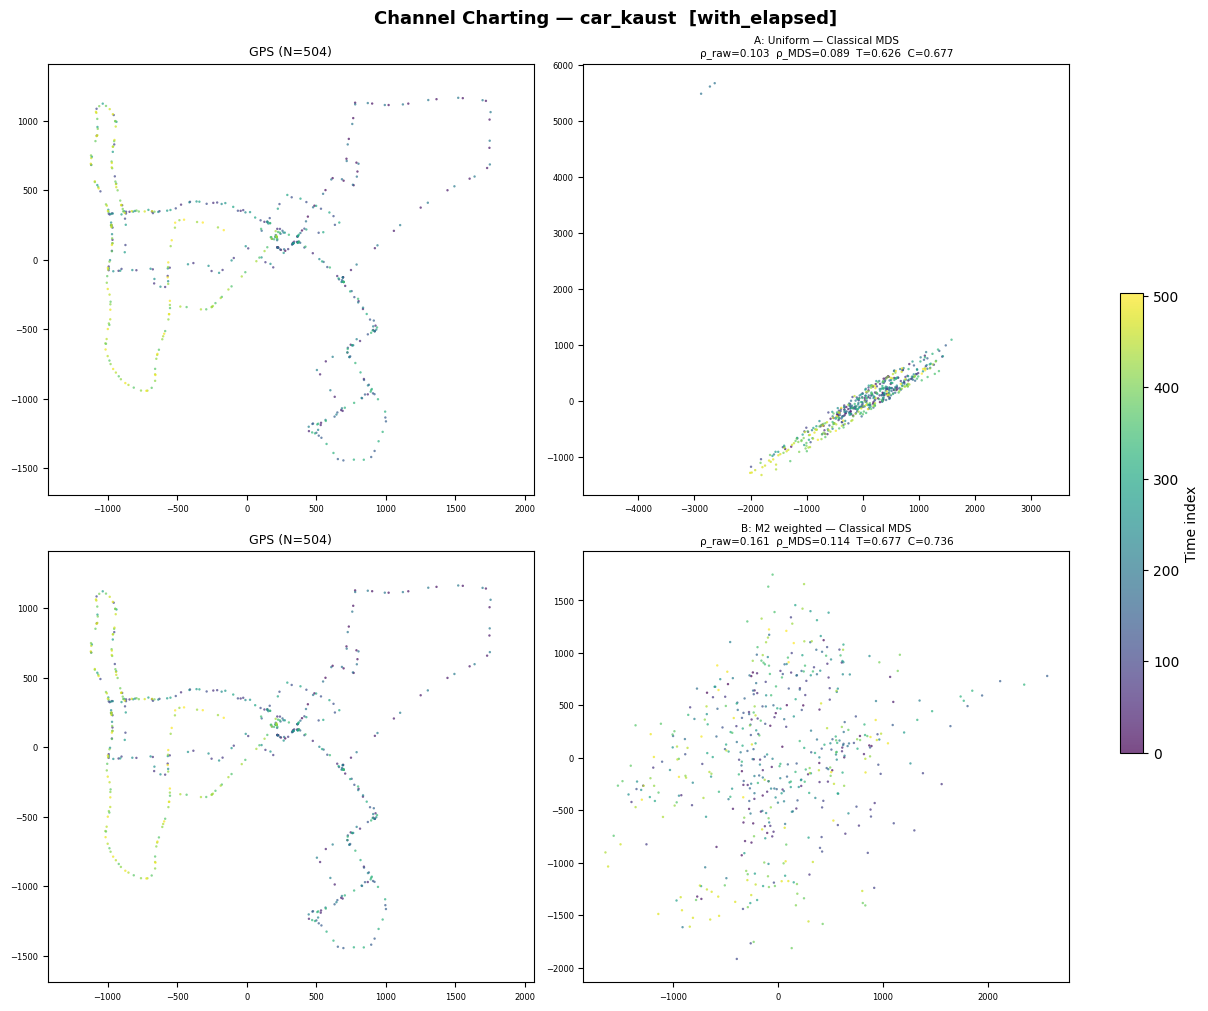

  (16s)

───────────────────────────────────────────────────────────────────────────
  car_kz  [with_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=2211, F=70, train=553, test=553
  Learning M2 weights (train only)...
  Active features: 9/70
    Pathloss (LTE pcell)                              20.2%
    Rank indication percentage - 3                    18.1%
    E-UTRAN carrier RSSI/antenna port - 10            16.1%
    E-UTRAN carrier RSSI/antenna port - 1             16.1%
    Rank indication percentage - 4                    11.0%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.1666 +0.0709 0.6019 0.6321
  B: M2 weighted         +0.3830 +0.3644 0.6594 0.7168
  C: Top-5 uniform       +0.3795 +0.3759 0.6618 0.7173

  Gain B−A (cMDS): +0.2935    Gain B−C (cMD

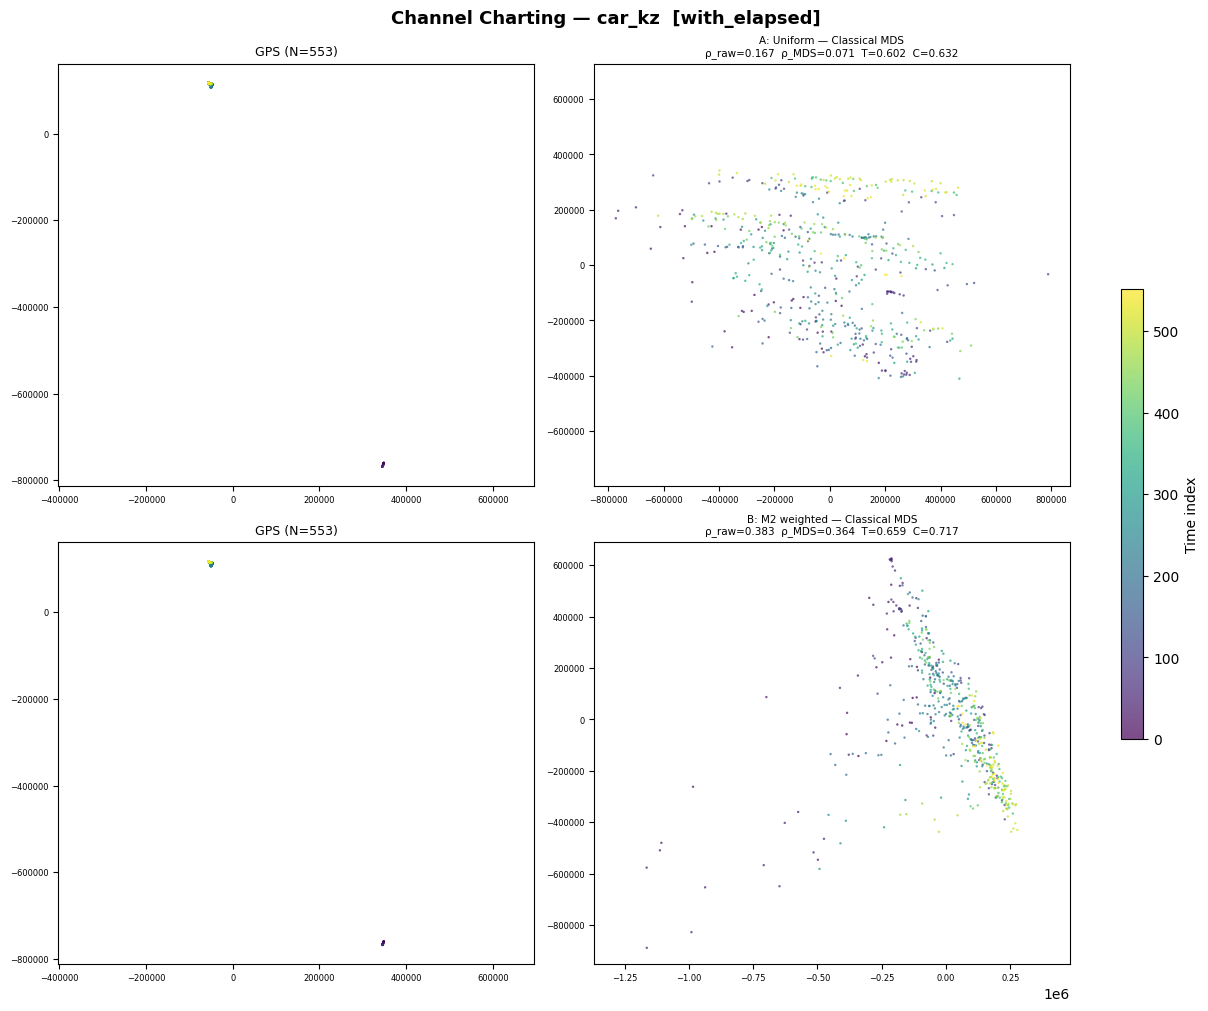

  (38s)

───────────────────────────────────────────────────────────────────────────
  car_mekkah  [with_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=2177, F=81, train=545, test=544
  Learning M2 weights (train only)...
  Active features: 8/81
    RSRQ/antenna port - 2                             20.9%
    E-UTRAN carrier RSSI/antenna port - 7             18.7%
    RSRQ/antenna port - 1                             17.9%
    E-UTRAN carrier RSSI/antenna port - 9             14.5%
    Pathloss (LTE pcell)                              11.4%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.1187 +0.1411 0.6006 0.6307
  B: M2 weighted         +0.3366 +0.3284 0.6539 0.7062
  C: Top-5 uniform       +0.3416 +0.3195 0.6415 0.6787

  Gain B−A (cMDS): +0.1873    Gain B−C 

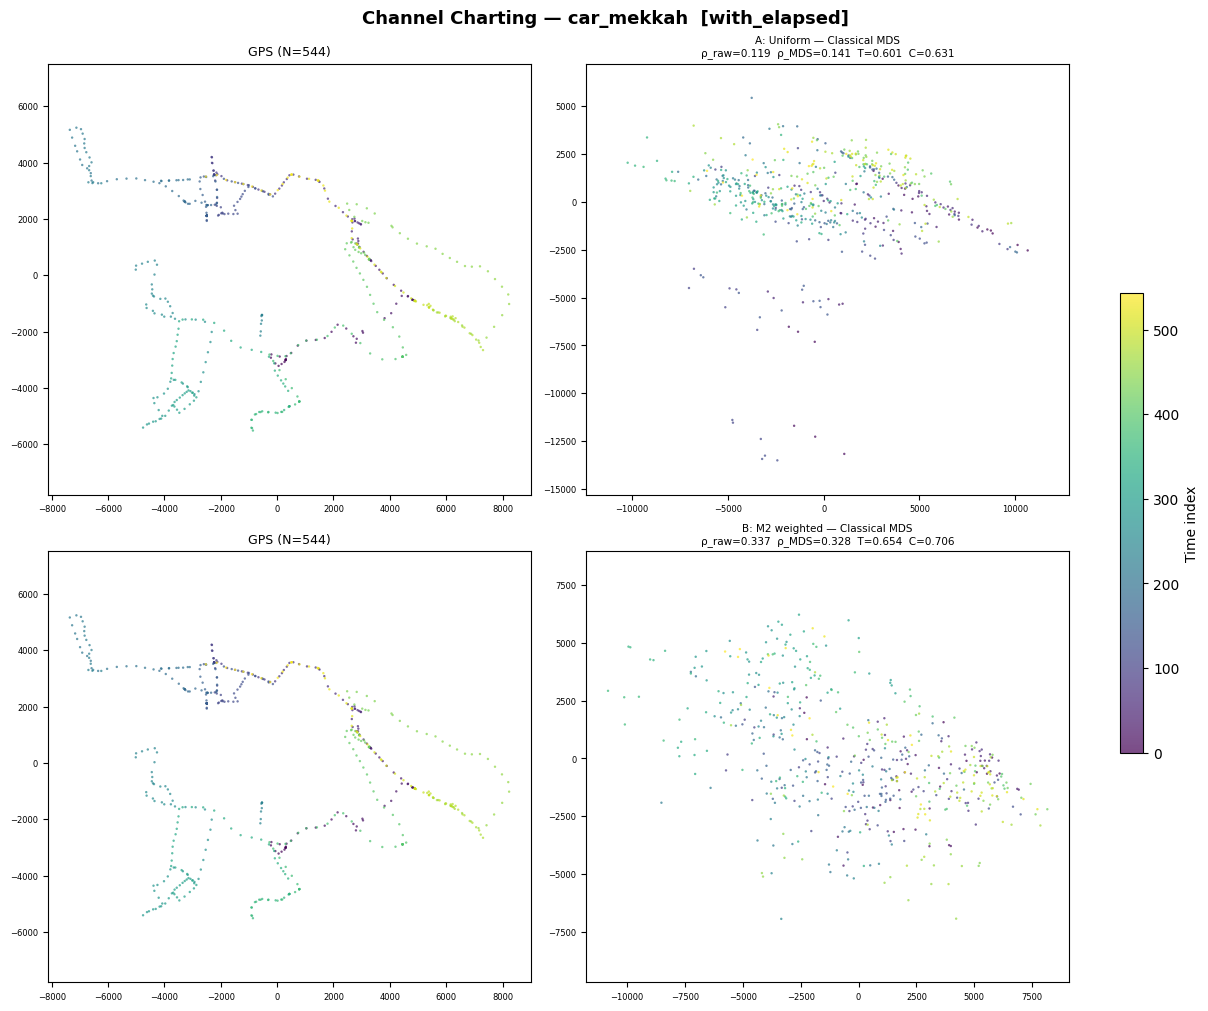

  (19s)

───────────────────────────────────────────────────────────────────────────
  walk_jeddah  [with_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=3923, F=69, train=981, test=981
  Learning M2 weights (train only)...
  Active features: 7/69
    CQI for codeword 0 per subband - 1                29.3%
    CQI for codeword 0 per subband - 2                28.9%
    RSRQ/antenna port - 2                             12.5%
    E-UTRAN carrier RSSI/antenna port - 8             11.5%
    E-UTRAN carrier RSSI/antenna port - 1              8.5%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.0964 +0.0908 0.6748 0.7485
  B: M2 weighted         +0.3722 +0.3214 0.6695 0.7515
  C: Top-5 uniform       +0.3554 +0.3000 0.6678 0.7531

  Gain B−A (cMDS): +0.2305    Gain B−C

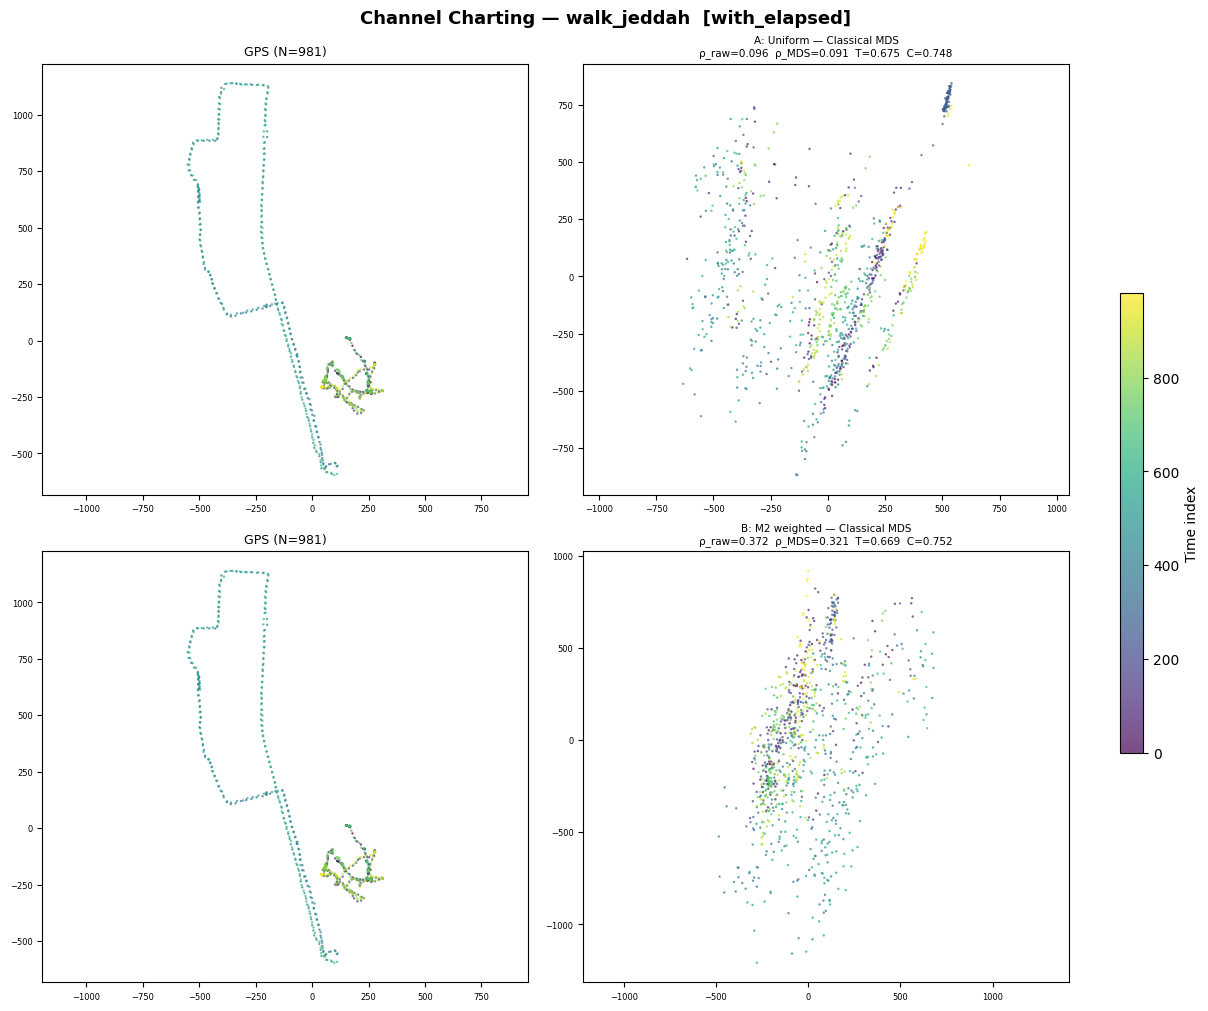

  (16s)

───────────────────────────────────────────────────────────────────────────
  walk_kaust  [with_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=14234, F=75, train=3559, test=3558
  Learning M2 weights (train only)...
  Active features: 5/75
    E-UTRAN carrier RSSI/antenna port - 6             29.5%
    elapsed_s                                         26.0%
    RSRQ/antenna port - 6                             16.8%
    CQI for codeword 0 per subband - 11               14.4%
    E-UTRAN carrier RSSI/antenna port - 3             13.3%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.1142 +0.0660 0.5946 0.6592
  B: M2 weighted         +0.2591 +0.2427 0.6341 0.6921
  C: Top-5 uniform       +0.2534 +0.2457 0.6338 0.6940

  Gain B−A (cMDS): +0.1767    Gain B

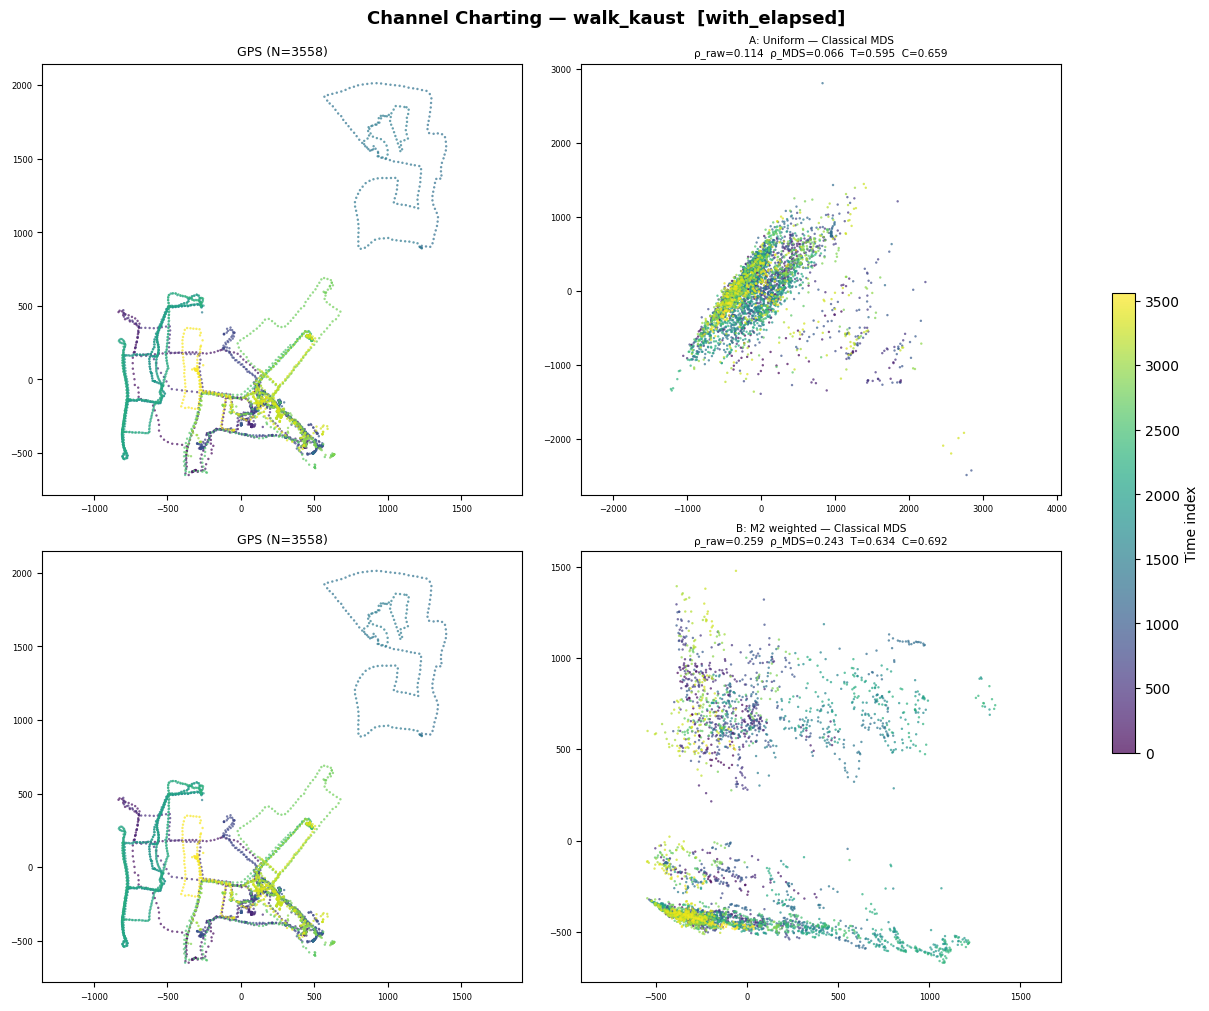

  (83s)

───────────────────────────────────────────────────────────────────────────
  walk_mekkah  [with_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=1910, F=81, train=478, test=477
  Learning M2 weights (train only)...
  Active features: 9/81
    RSRQ/antenna port - 8                             34.3%
    RSRQ/antenna port - 12                            28.2%
    RSRQ/antenna port - 2                             19.3%
    RSRQ/antenna port - 4                              5.8%
    RSRQ/antenna port - 6                              4.3%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.4195 +0.3920 0.7315 0.8080
  B: M2 weighted         +0.4478 +0.4199 0.7191 0.8063
  C: Top-5 uniform       +0.4179 +0.4199 0.7123 0.8192

  Gain B−A (cMDS): +0.0279    Gain B−C

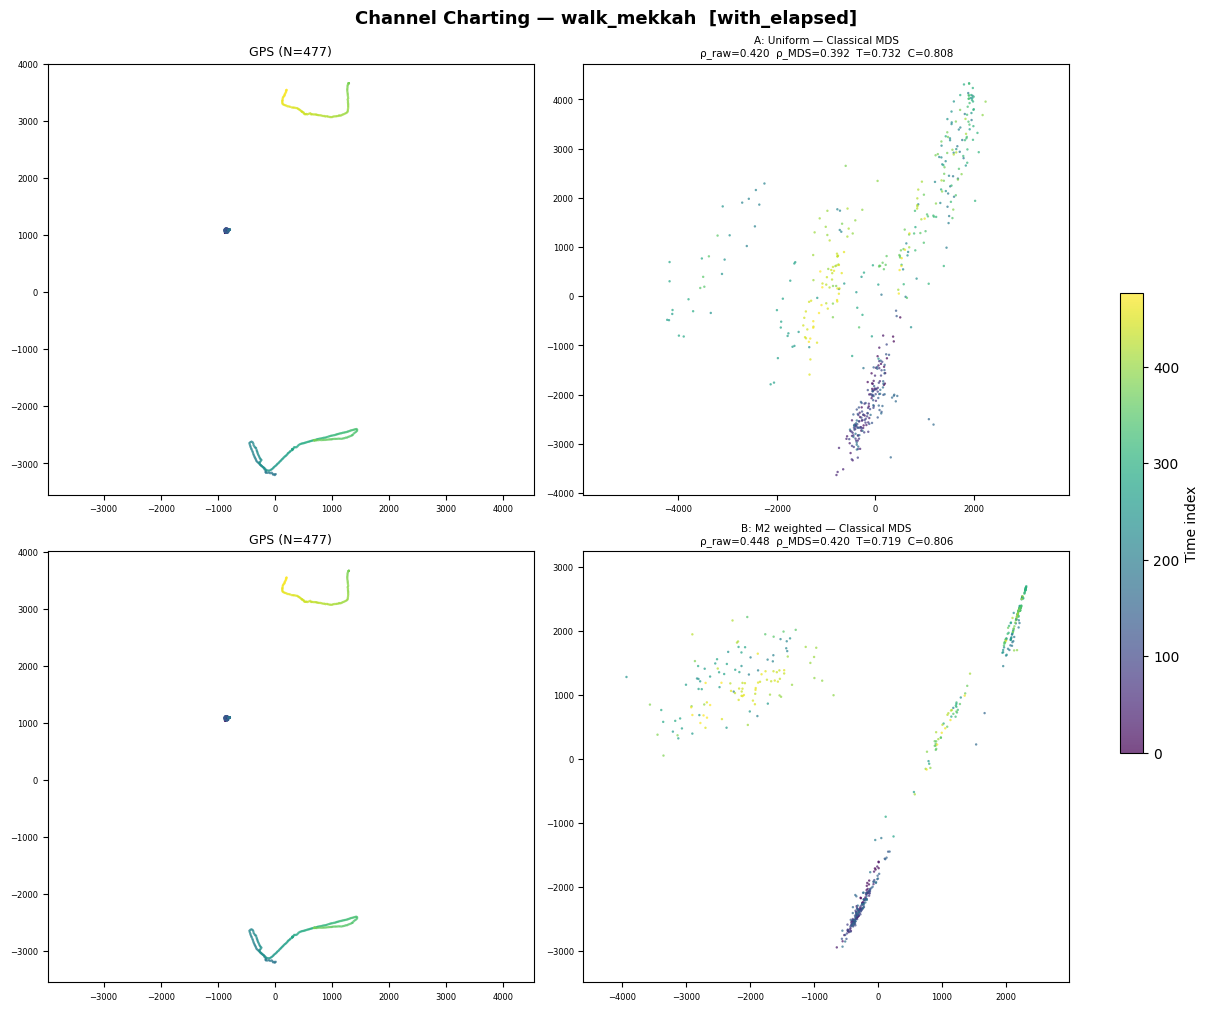

  (28s)

███████████████████████████████████████████████████████████████████████████
  MODE: NO ELAPSED
███████████████████████████████████████████████████████████████████████████

───────────────────────────────────────────────────────────────────────────
  bus_colored_kaust  [no_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=2828, F=68, train=707, test=707
  Learning M2 weights (train only)...
  Active features: 8/68
    Wideband CQI for codeword 1                       37.0%
    Timing advance                                    24.4%
    CQI for codeword 1 per subband - 12               10.9%
    E-UTRAN carrier RSSI/antenna port - 6              9.8%
    E-UTRAN carrier RSSI/antenna port - 2              9.4%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.

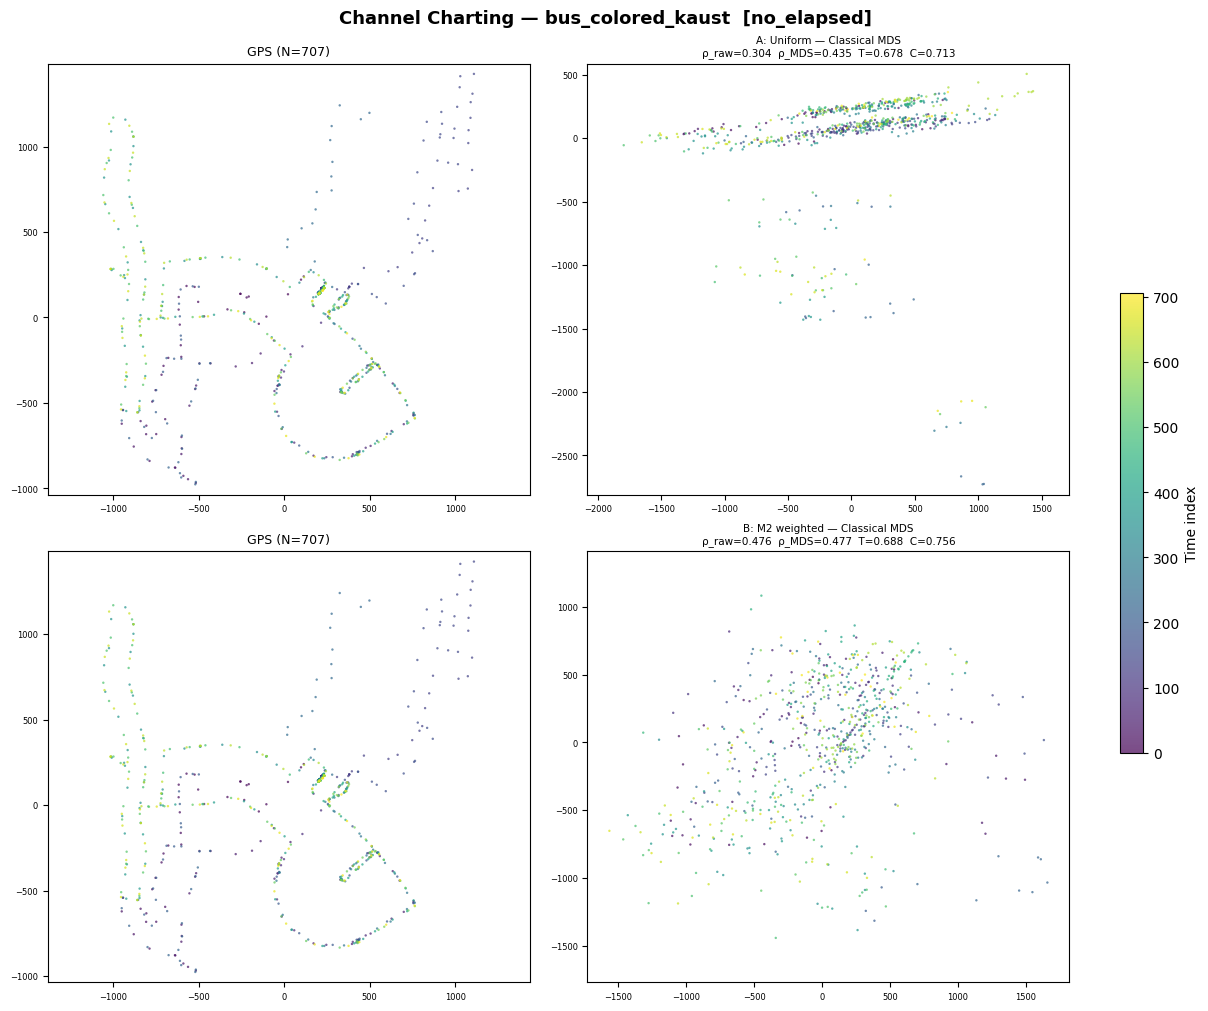

  (15s)

───────────────────────────────────────────────────────────────────────────
  bus_jeddah  [no_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=3446, F=68, train=862, test=861
  Learning M2 weights (train only)...
  Active features: 3/68
    Rank indication percentage - 2                    40.4%
    Timing advance                                    30.8%
    RSRQ/antenna port - 1                             28.8%
    Rank indication percentage - 1                     0.0%
    RSRP/antenna port - 2                              0.0%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.0964 +0.0512 0.5732 0.6569
  B: M2 weighted         +0.1223 +0.1342 0.6593 0.7310
  C: Top-5 uniform       +0.1229 +0.1280 0.6505 0.7265

  Gain B−A (cMDS): +0.0831    Gain B−C (c

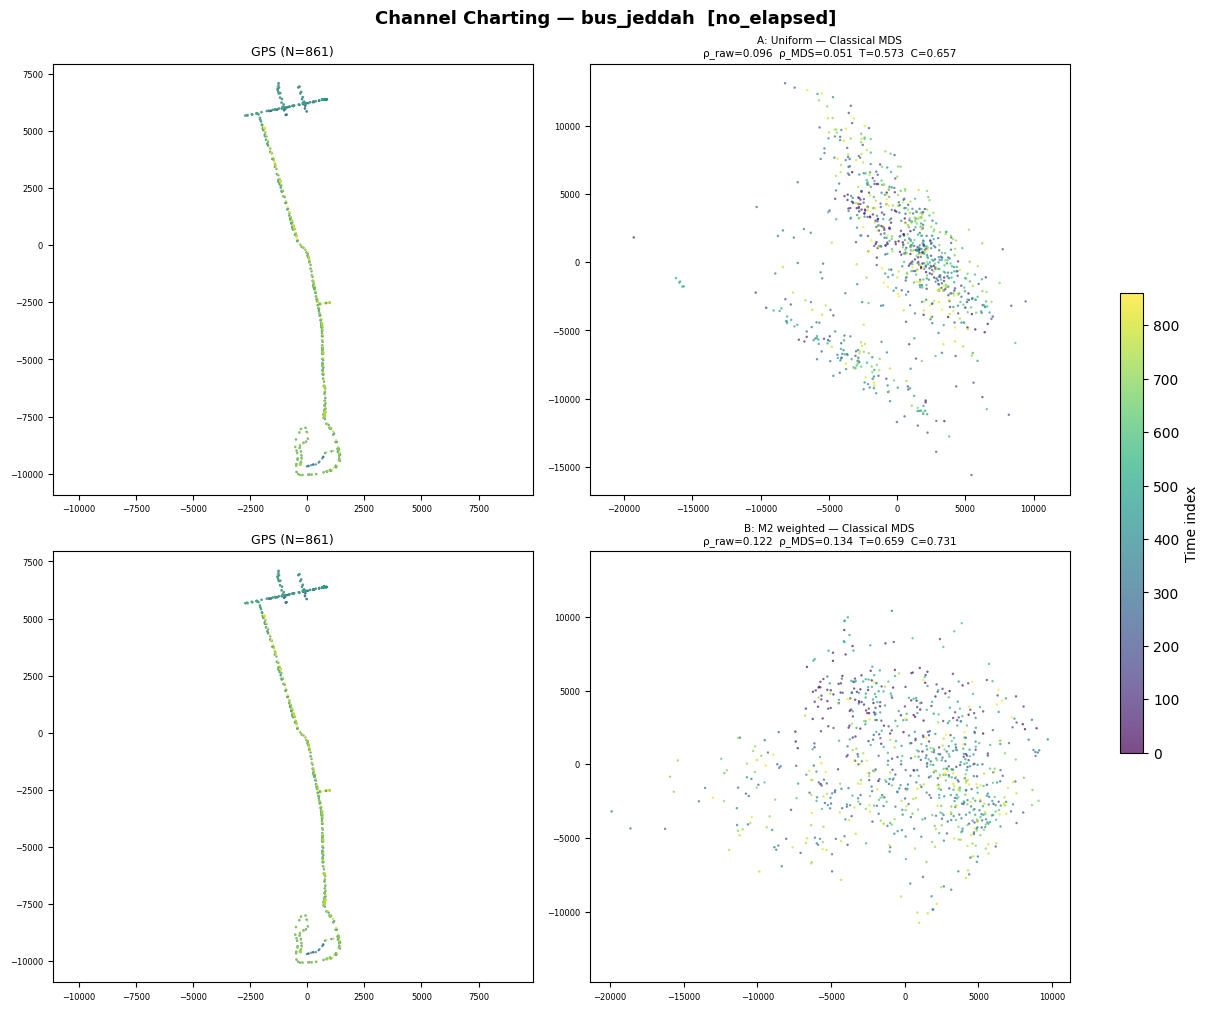

  (14s)

───────────────────────────────────────────────────────────────────────────
  bus_mekkah  [no_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=3856, F=80, train=964, test=964
  Learning M2 weights (train only)...
  Active features: 10/80
    CQI for codeword 0 per subband - 1                23.8%
    CQI for codeword 0 per subband - 11               18.3%
    CQI for codeword 0 per subband - 12                9.8%
    CQI for codeword 1 per subband - 11                8.7%
    RSRQ/antenna port - 1                              8.6%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.2006 +0.1472 0.5723 0.6773
  B: M2 weighted         +0.3507 +0.3357 0.6273 0.7086
  C: Top-5 uniform       +0.2881 +0.3164 0.6259 0.7115

  Gain B−A (cMDS): +0.1885    Gain B−C (

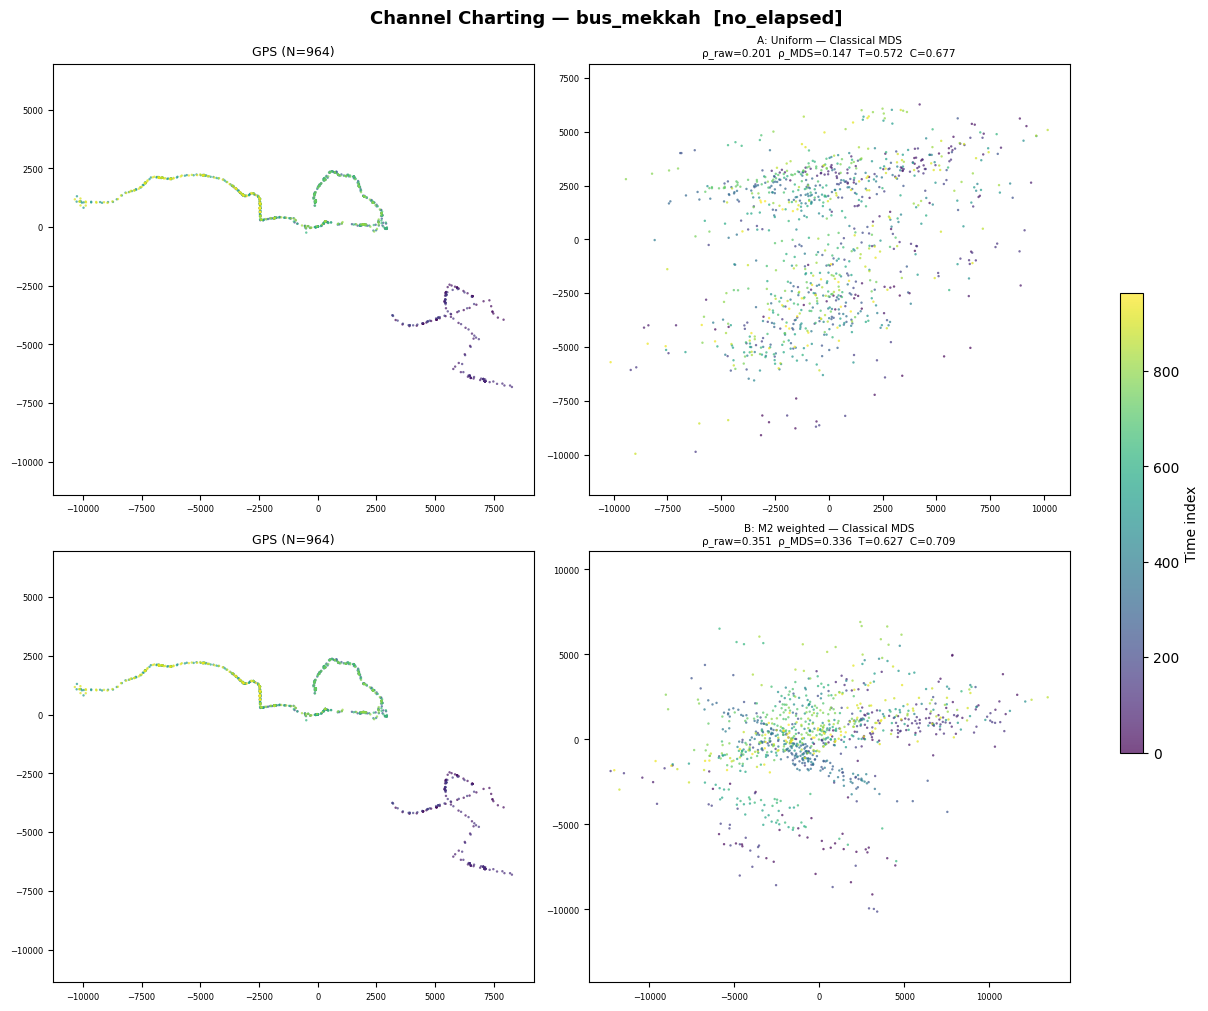

  (19s)

───────────────────────────────────────────────────────────────────────────
  car_jeddah  [no_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=4679, F=74, train=1170, test=1170
  Learning M2 weights (train only)...
  Active features: 9/74
    RSRQ/antenna port - 1                             22.8%
    RSRP/antenna port - 7                             19.4%
    RSRQ/antenna port - 2                             16.0%
    E-UTRAN carrier RSSI/antenna port - 2             12.0%
    RSRQ/antenna port - 3                             10.2%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.2397 +0.2853 0.6444 0.7139
  B: M2 weighted         +0.5212 +0.5211 0.7246 0.7976
  C: Top-5 uniform       +0.5070 +0.5123 0.7211 0.7941

  Gain B−A (cMDS): +0.2358    Gain B−C 

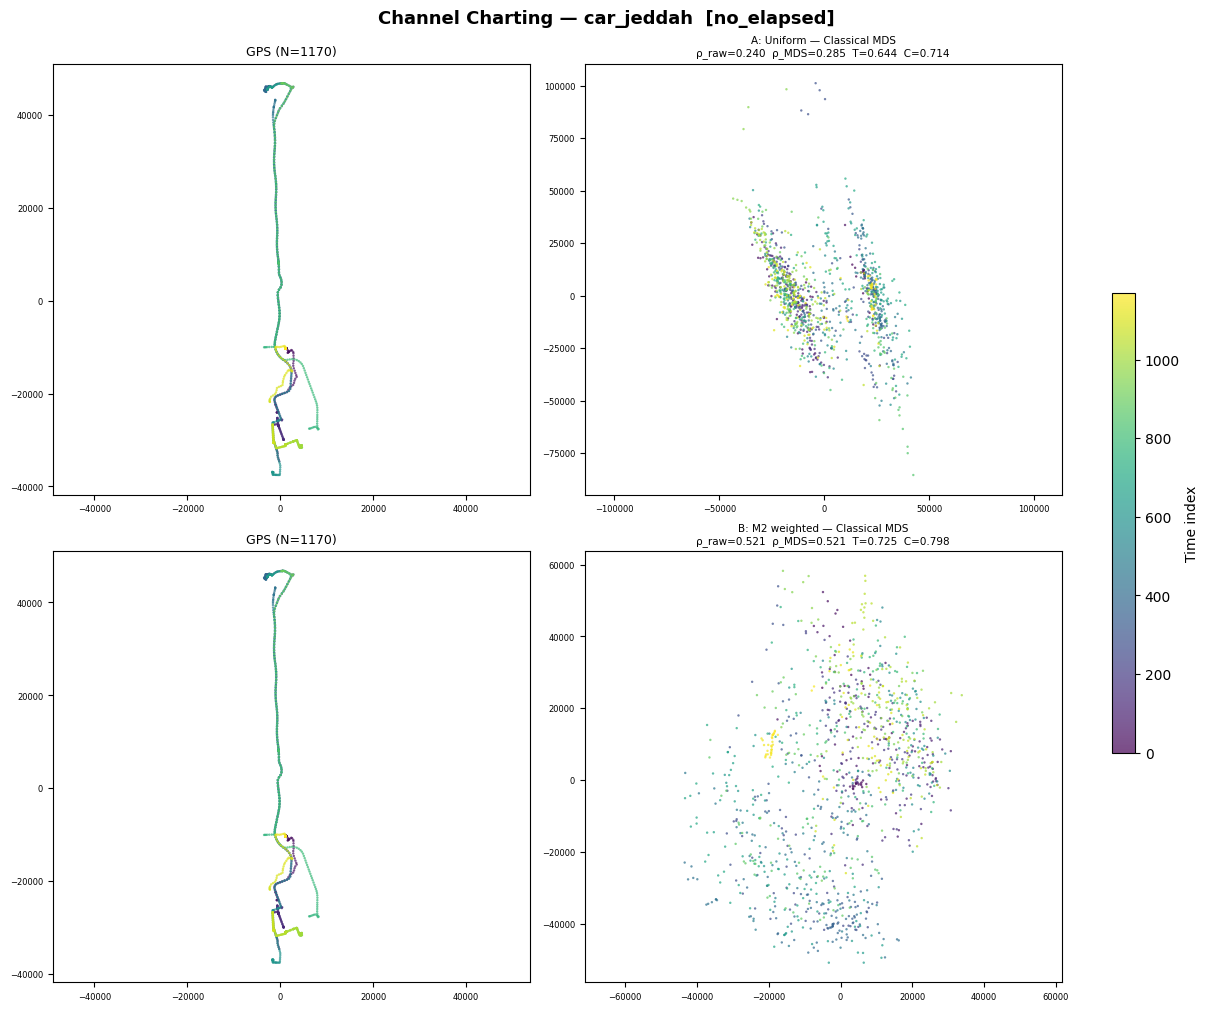

  (26s)

───────────────────────────────────────────────────────────────────────────
  car_kaust  [no_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=2016, F=68, train=504, test=504
  Learning M2 weights (train only)...
  Active features: 5/68
    CQI for codeword 1 per subband - 11               38.9%
    RSRQ/antenna port - 1                             22.5%
    E-UTRAN carrier RSSI/antenna port - 4             20.8%
    Timing advance                                    11.6%
    RSRP/antenna port - 2                              6.1%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.1054 +0.0880 0.6251 0.6761
  B: M2 weighted         +0.1614 +0.1143 0.6771 0.7361
  C: Top-5 uniform       +0.1674 +0.1275 0.6648 0.7391

  Gain B−A (cMDS): +0.0264    Gain B−C (cM

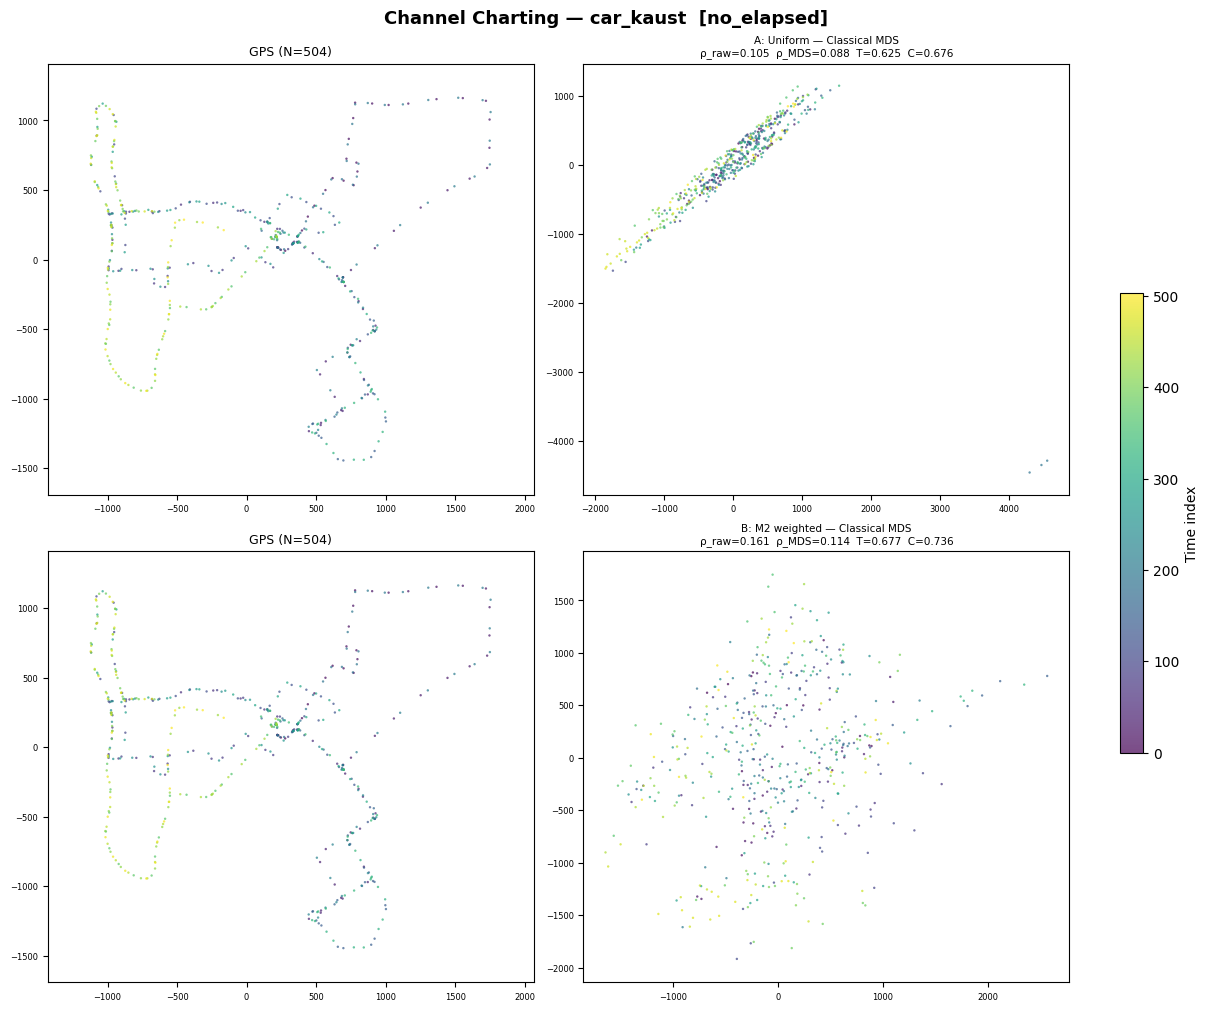

  (16s)

───────────────────────────────────────────────────────────────────────────
  car_kz  [no_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=2211, F=69, train=553, test=553
  Learning M2 weights (train only)...
  Active features: 9/69
    Pathloss (LTE pcell)                              20.8%
    Rank indication percentage - 3                    18.4%
    E-UTRAN carrier RSSI/antenna port - 10            16.1%
    E-UTRAN carrier RSSI/antenna port - 1             15.9%
    Rank indication percentage - 4                    11.3%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.1574 +0.0705 0.6010 0.6320
  B: M2 weighted         +0.3737 +0.3644 0.6605 0.7167
  C: Top-5 uniform       +0.3795 +0.3759 0.6618 0.7173

  Gain B−A (cMDS): +0.2939    Gain B−C (cMDS)

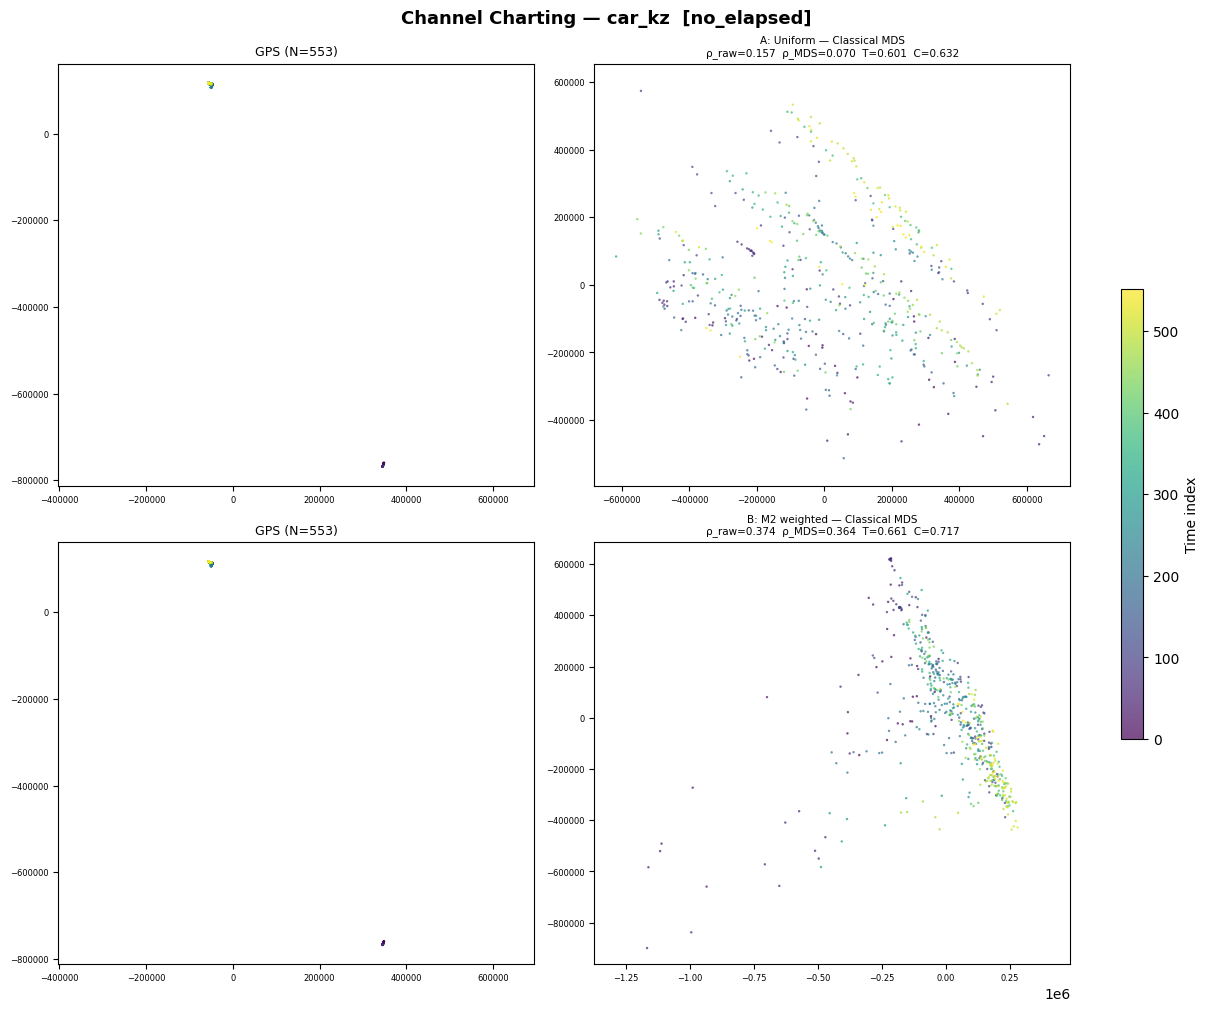

  (33s)

───────────────────────────────────────────────────────────────────────────
  car_mekkah  [no_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=2177, F=80, train=545, test=544
  Learning M2 weights (train only)...
  Active features: 8/80
    RSRQ/antenna port - 2                             20.9%
    E-UTRAN carrier RSSI/antenna port - 7             18.7%
    RSRQ/antenna port - 1                             17.9%
    E-UTRAN carrier RSSI/antenna port - 9             14.5%
    Pathloss (LTE pcell)                              11.4%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.1199 +0.1411 0.6020 0.6304
  B: M2 weighted         +0.3366 +0.3284 0.6538 0.7062
  C: Top-5 uniform       +0.3416 +0.3195 0.6415 0.6787

  Gain B−A (cMDS): +0.1873    Gain B−C (c

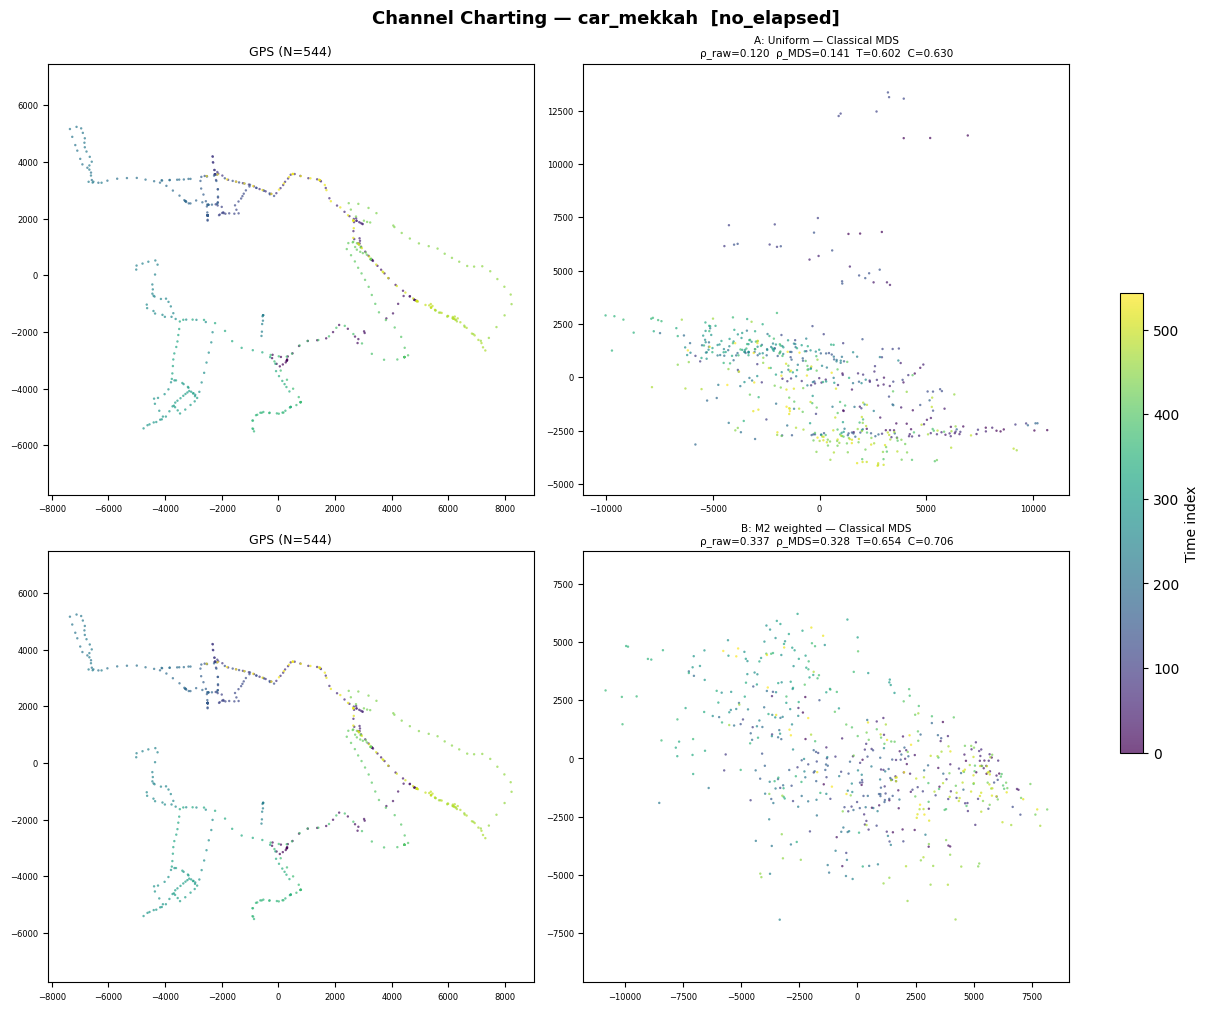

  (19s)

───────────────────────────────────────────────────────────────────────────
  walk_jeddah  [no_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=3923, F=68, train=981, test=981
  Learning M2 weights (train only)...
  Active features: 7/68
    CQI for codeword 0 per subband - 1                29.3%
    CQI for codeword 0 per subband - 2                28.9%
    RSRQ/antenna port - 2                             12.5%
    E-UTRAN carrier RSSI/antenna port - 8             11.5%
    E-UTRAN carrier RSSI/antenna port - 1              8.5%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.1008 +0.0921 0.6721 0.7474
  B: M2 weighted         +0.3722 +0.3214 0.6695 0.7515
  C: Top-5 uniform       +0.3554 +0.3000 0.6678 0.7531

  Gain B−A (cMDS): +0.2292    Gain B−C (

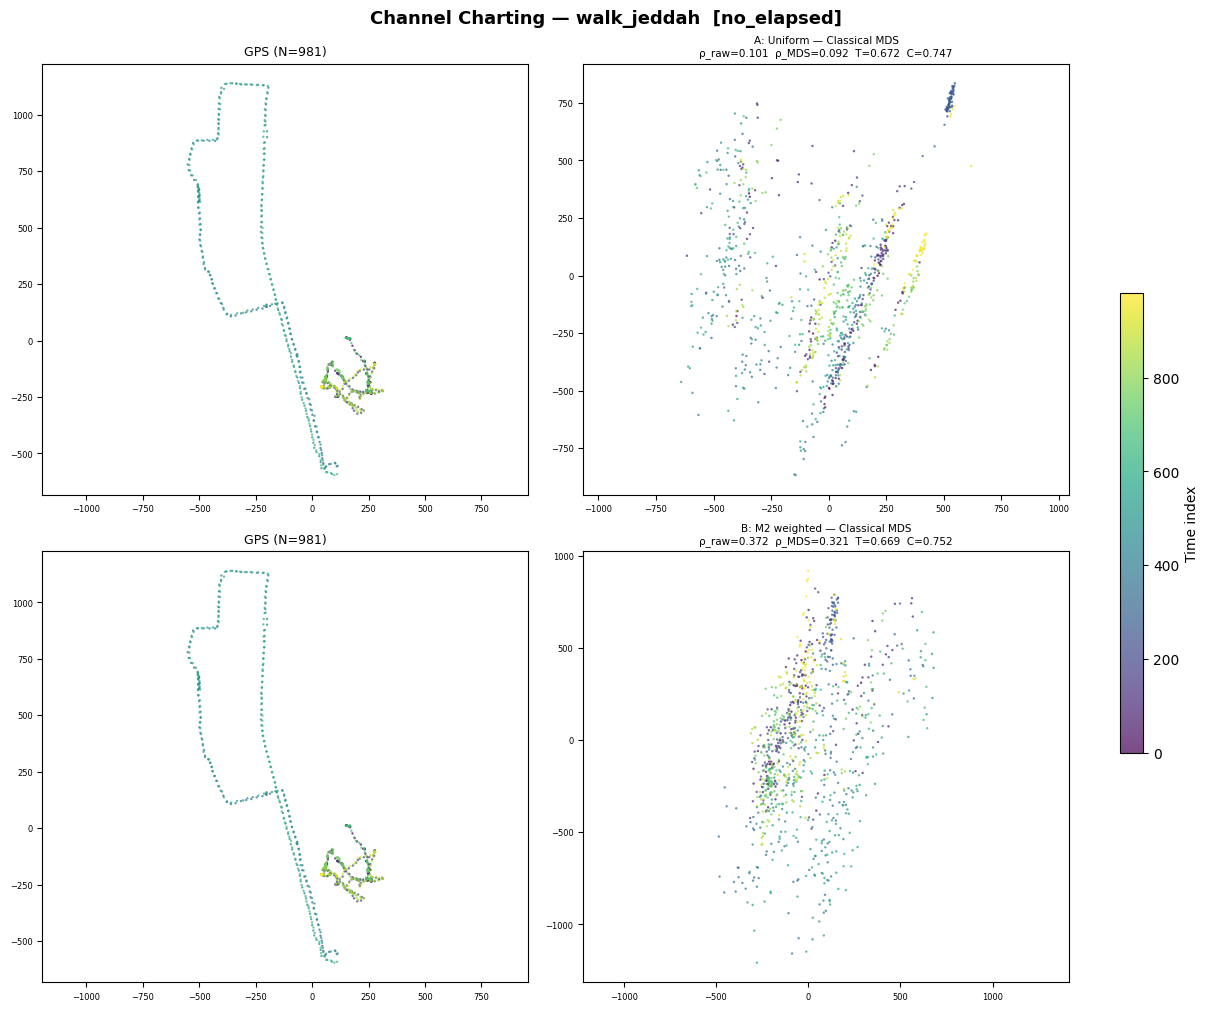

  (15s)

───────────────────────────────────────────────────────────────────────────
  walk_kaust  [no_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=14234, F=74, train=3559, test=3558
  Learning M2 weights (train only)...
  Active features: 3/74
    RSRQ/antenna port - 6                             53.8%
    E-UTRAN carrier RSSI/antenna port - 3             29.7%
    E-UTRAN carrier RSSI/antenna port - 6             16.5%
    RSRP/antenna port - 3                              0.0%
    E-UTRAN carrier RSSI/antenna port - 5              0.0%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.1067 +0.0661 0.5951 0.6594
  B: M2 weighted         +0.2004 +0.1915 0.6290 0.6858
  C: Top-5 uniform       +0.1970 +0.1978 0.6578 0.6886

  Gain B−A (cMDS): +0.1254    Gain B−C

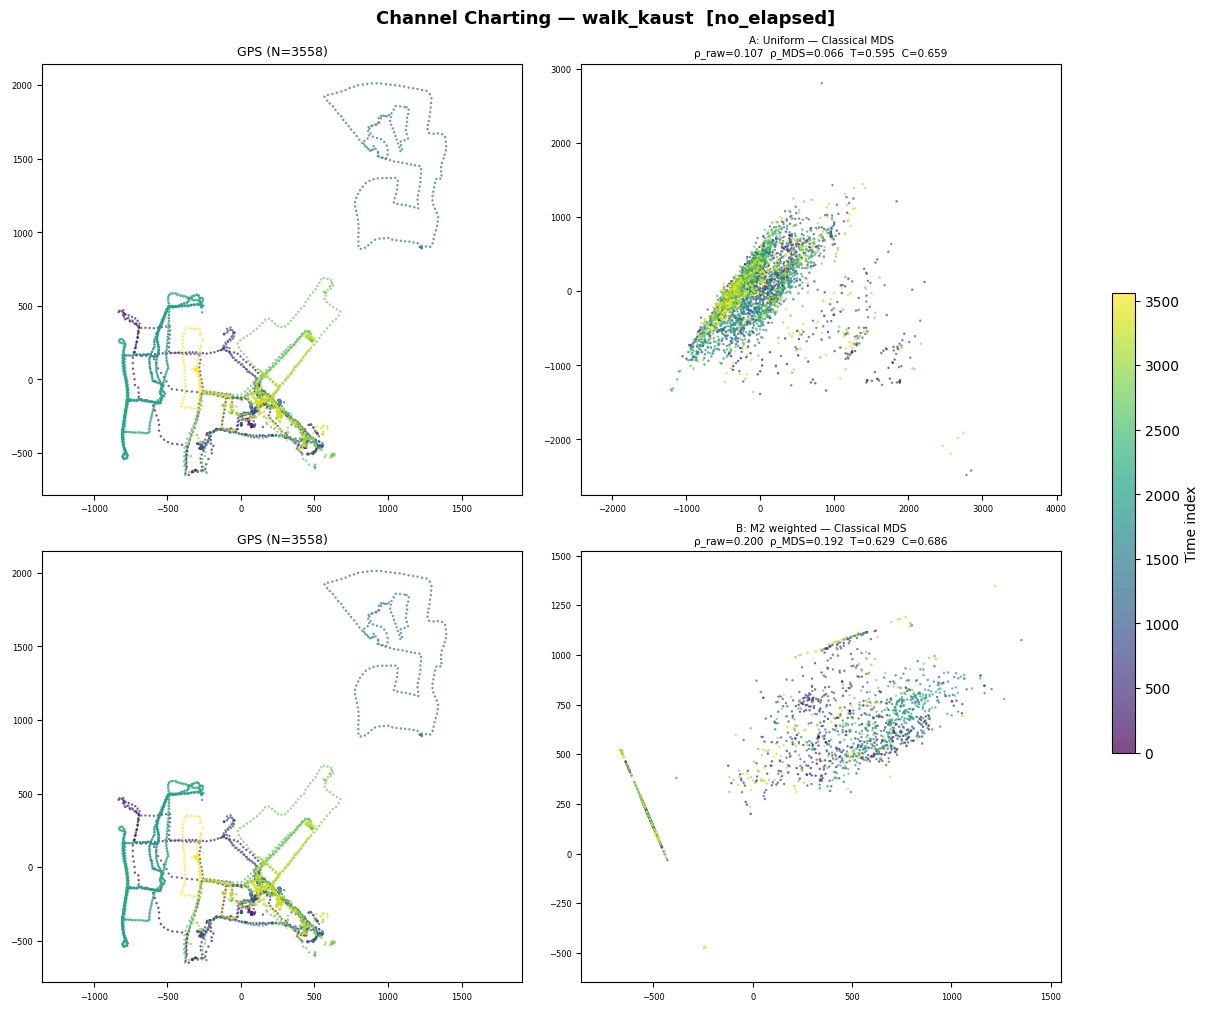

  (77s)

───────────────────────────────────────────────────────────────────────────
  walk_mekkah  [no_elapsed]
───────────────────────────────────────────────────────────────────────────
  N=1910, F=80, train=478, test=477
  Learning M2 weights (train only)...
  Active features: 9/80
    RSRQ/antenna port - 8                             34.3%
    RSRQ/antenna port - 12                            28.2%
    RSRQ/antenna port - 2                             19.3%
    RSRQ/antenna port - 4                              5.8%
    RSRQ/antenna port - 6                              4.3%
  [A] Uniform weights...
  [B] M2 learned weights...
  [C] Top-5 M2 features, uniform weight...

  Baseline                 ρ raw  ρ cMDS      T      C
  ────────────────────── ─────── ─────── ────── ──────
  A: Uniform             +0.4220 +0.3931 0.7314 0.8076
  B: M2 weighted         +0.4479 +0.4199 0.7191 0.8063
  C: Top-5 uniform       +0.4179 +0.4199 0.7123 0.8192

  Gain B−A (cMDS): +0.0268    Gain B−C (

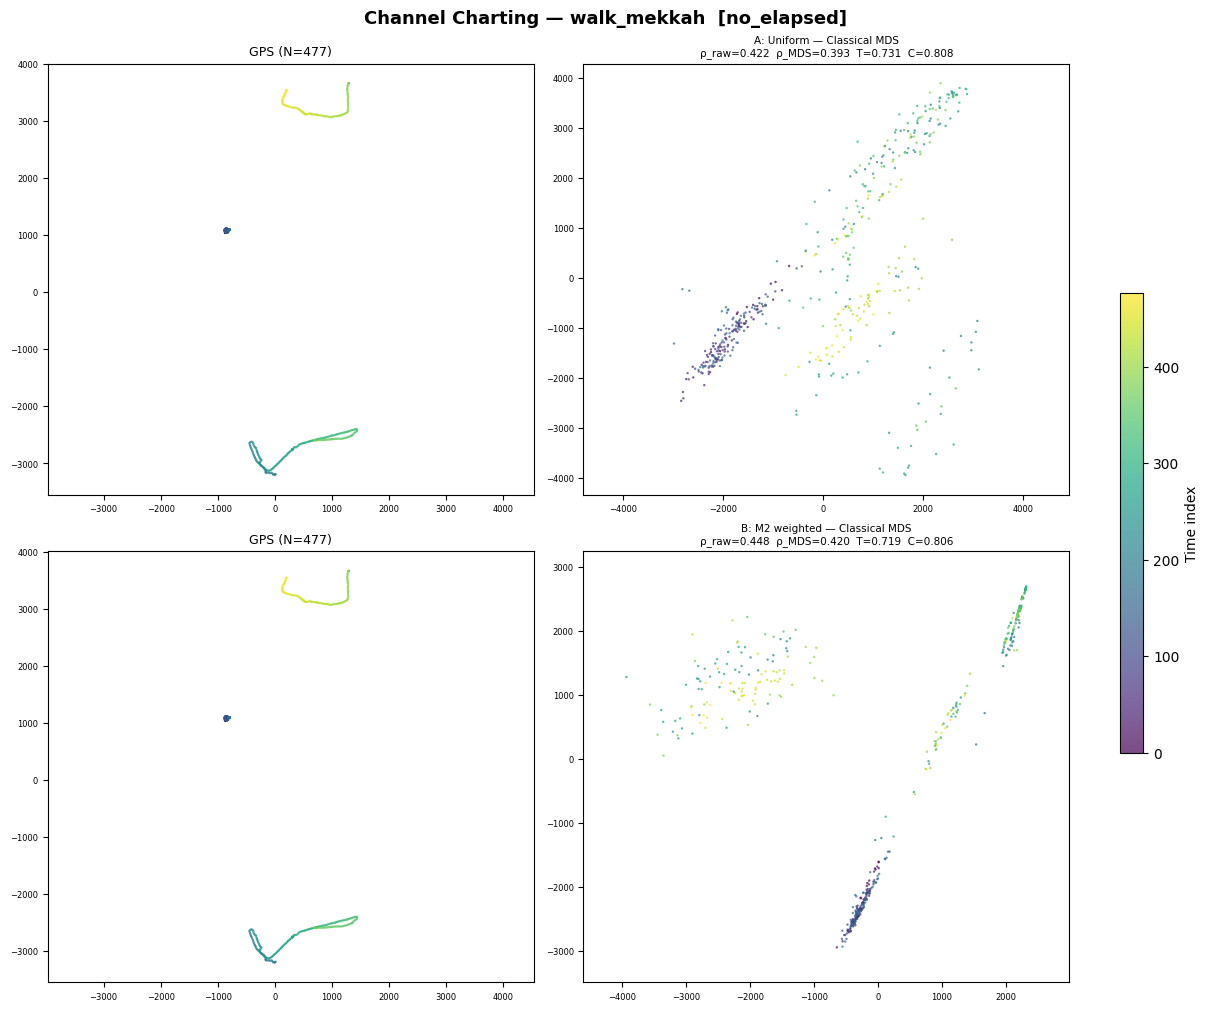

  (26s)

✓ Main loop complete!


In [ ]:
SKIP_DATASETS = {'train_mekkah', 'walk_kz'}

datasets = sorted(
    d.name for d in pathlib.Path('CellMob').iterdir()
    if d.is_dir()
    and not d.name.startswith('.')
    and d.name not in SKIP_DATASETS
)

fig_dir = pathlib.Path(OUTPUT_DIR)
fig_dir.mkdir(parents=True, exist_ok=True)

csv_rows = []
all_weight_info = {}

print('=' * 75)
print('  CHANNEL CHARTING WITH LEARNED FEATURE WEIGHTS')
print('=' * 75)

for include_elapsed in [True, False]:
    elapsed_tag = 'with_elapsed' if include_elapsed else 'no_elapsed'
    print(f'\n{"█" * 75}')
    print(f'  MODE: {elapsed_tag.upper().replace("_", " ")}')
    print(f'{"█" * 75}')

    for ds in datasets:
        t0 = time.time()
        print(f'\n{"─" * 75}')
        print(f'  {ds}  [{elapsed_tag}]')
        print(f'{"─" * 75}')

        # Load
        df = load_dataset(ds)
        sig_cols = sorted(c for c in df.columns
                          if c not in EXCLUDE_COLS and df[c].dtype != object)
        if not sig_cols:
            print('  No signal columns → skipping.')
            continue

        X, D_gt, pos, feat_names = build_features(df, sig_cols, include_elapsed)
        N, F = X.shape

        tr_idx, te_idx = decimation_split(N)
        if len(tr_idx) < 50 or len(te_idx) < 50:
            print(f'  Too few bins (N={N}) → skipping.')
            continue
        print(f'  N={N}, F={F}, train={len(tr_idx)}, test={len(te_idx)}')

        # Preprocess (train-only impute + standardise)
        Xs = preprocess(X, tr_idx)
        X_tr   = Xs[tr_idx]
        X_te   = Xs[te_idx]
        Dgt_tr = D_gt[np.ix_(tr_idx, tr_idx)]
        Dgt_te = D_gt[np.ix_(te_idx, te_idx)]
        pos_te = pos[te_idx]

        # Learn M2 weights on TRAIN
        print('  Learning M2 weights (train only)...')
        w_m2 = learn_m2_weights(X_tr, Dgt_tr)
        active = int(np.sum(w_m2 > 1e-4))
        top_idx = np.argsort(w_m2)[::-1][:TOP_K]
        print(f'  Active features: {active}/{F}')
        for fi in top_idx:
            print(f'    {feat_names[fi]:<48} {100*w_m2[fi]:5.1f}%')

        all_weight_info[(ds, elapsed_tag)] = [
            (feat_names[fi], w_m2[fi]) for fi in top_idx]

        # Baseline A: uniform weights
        print('  [A] Uniform weights...')
        w_uni = np.ones(F) / F
        res_a = run_embedding_pipeline(X_te, Dgt_te, pos_te, w_uni, 'A: Uniform')

        # Baseline B: M2 learned weights
        print('  [B] M2 learned weights...')
        res_b = run_embedding_pipeline(X_te, Dgt_te, pos_te, w_m2, 'B: M2 weighted')

        # Baseline C: top-k M2 features, uniform among them
        print(f'  [C] Top-{TOP_K} M2 features, uniform weight...')
        w_topk = np.zeros(F)
        w_topk[top_idx] = 1.0 / TOP_K
        res_c = run_embedding_pipeline(X_te, Dgt_te, pos_te, w_topk,
                                       f'C: Top-{TOP_K} uniform')

        # Print results
        print(f'\n  {"Baseline":<22} {"ρ raw":>7} {"ρ cMDS":>7} '
              f'{"T":>6} {"C":>6}')
        print(f'  {"─"*22} {"─"*7} {"─"*7} {"─"*6} {"─"*6}')
        for res in [res_a, res_b, res_c]:
            print(f'  {res["label"]:<22} '
                  f'{res["rho_raw"]:>+.4f} {res["rho_cls"]:>+.4f} '
                  f'{res["T_cls"]:>.4f} {res["C_cls"]:>.4f}')

        # Gains
        gain_ba = res_b['rho_cls'] - res_a['rho_cls']
        gain_bc = res_b['rho_cls'] - res_c['rho_cls']
        print(f'\n  Gain B−A (cMDS): {gain_ba:+.4f}'
              f'    Gain B−C (cMDS): {gain_bc:+.4f}')

        # CSV rows
        gain_ba_raw = round(res_b['rho_raw'] - res_a['rho_raw'], 4)
        gain_ba_cls = round(res_b['rho_cls'] - res_a['rho_cls'], 4)
        gain_bc_raw = round(res_b['rho_raw'] - res_c['rho_raw'], 4)
        gain_bc_cls = round(res_b['rho_cls'] - res_c['rho_cls'], 4)

        for res in [res_a, res_b, res_c]:
            top_feats = '; '.join(
                f'{feat_names[fi]}({100*w_m2[fi]:.0f}%)' for fi in top_idx
            ) if res['label'].startswith('B') else ''
            csv_rows.append({
                'dataset':      ds,
                'elapsed_s':    elapsed_tag,
                'baseline':     res['label'],
                'N_test':       res['N'],
                'rho_raw':      round(res['rho_raw'], 4),
                'rho_cMDS':     round(res['rho_cls'], 4),
                'T_cMDS':       round(res['T_cls'], 4),
                'C_cMDS':       round(res['C_cls'], 4),
                'gain_B-A_raw':  gain_ba_raw,
                'gain_B-A_cMDS': gain_ba_cls,
                'gain_B-C_raw':  gain_bc_raw,
                'gain_B-C_cMDS': gain_bc_cls,
                'M2_top_features': top_feats,
            })

        # Plot (Baseline A vs B)
        plot_channel_chart(res_a, res_b, ds, elapsed_tag, fig_dir)
        print(f'  ({time.time()-t0:.0f}s)')

print('\n✓ Main loop complete!')


## 11. Save CSV Summary

In [ ]:
csv_path = fig_dir / 'cc_summary.csv'
df_csv = pd.DataFrame(csv_rows)
df_csv.to_csv(csv_path, index=False)
print(f'✓ CSV saved → {csv_path}')
print(f'  {len(df_csv)} rows, columns: {list(df_csv.columns)}')
df_csv.head(12)


✓ CSV saved → /content/drive/MyDrive/cell_mob/figures_cc_v5/cc_summary.csv
  60 rows, columns: ['dataset', 'elapsed_s', 'baseline', 'N_test', 'rho_raw', 'rho_cMDS', 'T_cMDS', 'C_cMDS', 'gain_B-A_raw', 'gain_B-A_cMDS', 'gain_B-C_raw', 'gain_B-C_cMDS', 'M2_top_features']


,dataset,elapsed_s,baseline,N_test,rho_raw,rho_cMDS,T_cMDS,C_cMDS,gain_B-A_raw,gain_B-A_cMDS,gain_B-C_raw,gain_B-C_cMDS,M2_top_features
0,bus_colored_kaust,with_elapsed,A: Uniform,707,0.3017,0.4346,0.6775,0.7134,0.1743,0.0420,0.0330,0.0223,
1,bus_colored_kaust,with_elapsed,B: M2 weighted,707,0.4760,0.4766,0.6884,0.7562,0.1743,0.0420,0.0330,0.0223,Wideband CQI for codeword 1(37%); Timing advan...
2,bus_colored_kaust,with_elapsed,C: Top-5 uniform,707,0.4429,0.4543,0.6854,0.7621,0.1743,0.0420,0.0330,0.0223,
3,bus_jeddah,with_elapsed,A: Uniform,861,0.1081,0.0507,0.5761,0.6573,0.2904,0.3164,0.1526,0.1540,
4,bus_jeddah,with_elapsed,B: M2 weighted,861,0.3985,0.3671,0.7990,0.7366,0.2904,0.3164,0.1526,0.1540,elapsed_s(65%); Rank indication percentage - 2...
5,bus_jeddah,with_elapsed,C: Top-5 uniform,861,0.2459,0.2131,0.6832,0.7426,0.2904,0.3164,0.1526,0.1540,
6,bus_mekkah,with_elapsed,A: Uniform,964,0.1999,0.1471,0.5730,0.6773,0.1508,0.1886,0.0626,0.0193,
7,bus_mekkah,with_elapsed,B: M2 weighted,964,0.3507,0.3357,0.6273,0.7086,0.1508,0.1886,0.0626,0.0193,CQI for codeword 0 per subband - 1(24%); CQI f...
8,bus_mekkah,with_elapsed,C: Top-5 uniform,964,0.2881,0.3164,0.6259,0.7115,0.1508,0.1886,0.0626,0.0193,
9,car_jeddah,with_elapsed,A: Uniform,1170,0.2521,0.2914,0.6501,0.7155,0.3213,0.2627,0.0139,-0.0018,


## 12. Summary Charts

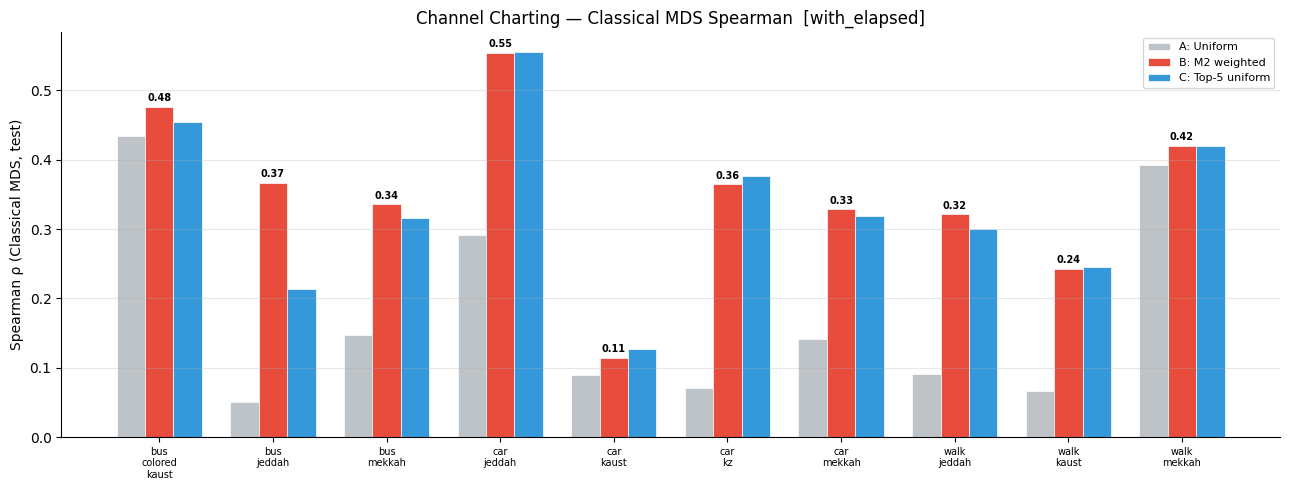

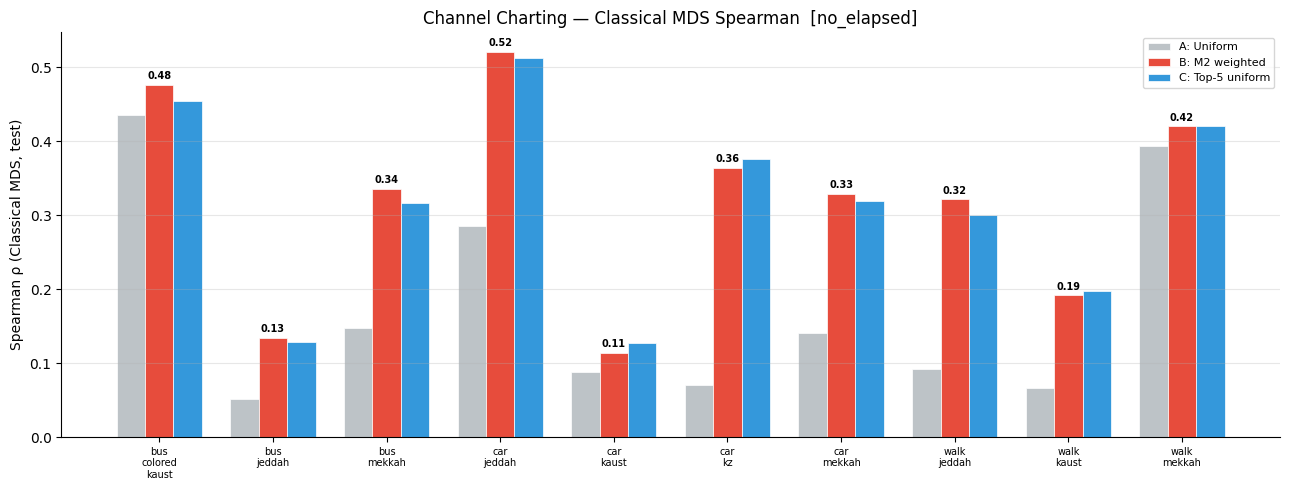

✓ Summary charts saved


In [ ]:
ds_done = [d for d in datasets if d in df_csv['dataset'].values]

for etag in ['with_elapsed', 'no_elapsed']:
    sub = df_csv[df_csv['elapsed_s'] == etag]
    if sub.empty:
        continue

    fig, ax = plt.subplots(figsize=(13, 5))
    x = np.arange(len(ds_done))
    x_labels = [d.replace('_', '\n') for d in ds_done]
    bar_w = 0.25
    colours = ['#bdc3c7', '#e74c3c', '#3498db']

    for i, bl in enumerate(['A: Uniform', 'B: M2 weighted',
                            f'C: Top-{TOP_K} uniform']):
        vals = []
        for d in ds_done:
            row = sub[(sub['dataset'] == d) & (sub['baseline'] == bl)]
            vals.append(row['rho_cMDS'].values[0] if len(row) else 0)
        ax.bar(x + (i - 1) * bar_w, vals, bar_w,
               label=bl, color=colours[i], edgecolor='white', linewidth=0.5)
        if bl.startswith('B'):
            for xi, v in zip(x + (i - 1) * bar_w, vals):
                ax.text(xi, v + 0.005, f'{v:.2f}', ha='center',
                        va='bottom', fontsize=7, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=7)
    ax.set_ylabel('Spearman ρ (Classical MDS, test)')
    ax.set_title(f'Channel Charting — Classical MDS Spearman  [{etag}]')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()
    fig.savefig(fig_dir / f'cc_summary_{etag}.png', dpi=200)
    plt.show()
    plt.close(fig)

print('✓ Summary charts saved')


## 13. Elapsed-Time Ablation

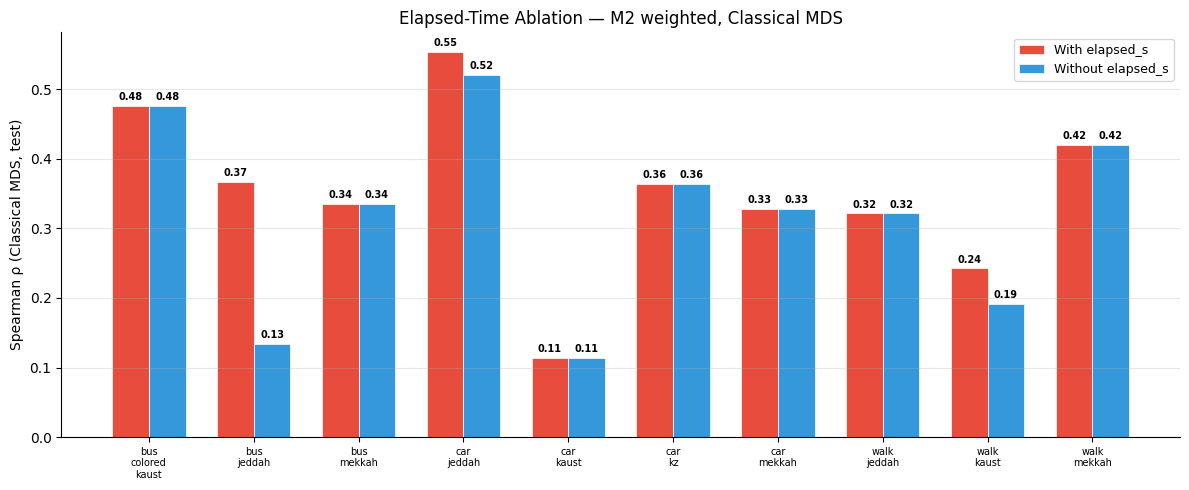

✓ Elapsed ablation chart saved


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(ds_done))
x_labels = [d.replace('_', '\n') for d in ds_done]

for i, etag in enumerate(['with_elapsed', 'no_elapsed']):
    sub = df_csv[(df_csv['elapsed_s'] == etag) &
                 (df_csv['baseline'] == 'B: M2 weighted')]
    vals = []
    for d in ds_done:
        row = sub[sub['dataset'] == d]
        vals.append(row['rho_cMDS'].values[0] if len(row) else 0)
    label = 'With elapsed_s' if i == 0 else 'Without elapsed_s'
    color = '#e74c3c' if i == 0 else '#3498db'
    ax.bar(x + (i - 0.5) * 0.35, vals, 0.35, label=label, color=color,
           edgecolor='white', linewidth=0.5)
    for xi, v in zip(x + (i - 0.5) * 0.35, vals):
        ax.text(xi, v + 0.005, f'{v:.2f}', ha='center', va='bottom',
                fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=7)
ax.set_ylabel('Spearman ρ (Classical MDS, test)')
ax.set_title('Elapsed-Time Ablation — M2 weighted, Classical MDS')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
fig.savefig(fig_dir / 'cc_elapsed_ablation.png', dpi=200)
plt.show()
plt.close(fig)

print('✓ Elapsed ablation chart saved')


## 14. Done — Results on Google Drive

In [ ]:
# All outputs are already saved to your Google Drive!
import os

out_files = sorted(os.listdir(fig_dir))
print(f'✓ {len(out_files)} files saved to: {fig_dir}')
print(f'  (This persists after runtime disconnects)\n')
for f in out_files:
    size_kb = os.path.getsize(fig_dir / f) / 1024
    print(f'  {f:<50} {size_kb:6.1f} KB')

print(f'\nFind them in Google Drive → cell_mob → figures_cc_v5')


✓ 24 files saved to: /content/drive/MyDrive/cell_mob/figures_cc_v5
  (This persists after runtime disconnects)

  cc_bus_colored_kaust_no_elapsed.png                 348.9 KB
  cc_bus_colored_kaust_with_elapsed.png               348.1 KB
  cc_bus_jeddah_no_elapsed.png                        359.5 KB
  cc_bus_jeddah_with_elapsed.png                      366.2 KB
  cc_bus_mekkah_no_elapsed.png                        375.6 KB
  cc_bus_mekkah_with_elapsed.png                      375.1 KB
  cc_car_jeddah_no_elapsed.png                        382.9 KB
  cc_car_jeddah_with_elapsed.png                      378.4 KB
  cc_car_kaust_no_elapsed.png                         304.9 KB
  cc_car_kaust_with_elapsed.png                       302.0 KB
  cc_car_kz_no_elapsed.png                            234.7 KB
  cc_car_kz_with_elapsed.png                          235.7 KB
  cc_car_mekkah_no_elapsed.png                        336.8 KB
  cc_car_mekkah_with_elapsed.png                      330.9 KB
  cc_e